# Counterfactuals: what a FRET model could say about *this* molecule

A FRET model today answers questions of the first kind: given these bursts, what
are the distances? Two further kinds of question are within reach, and the
experiments already make them:

| Level | Question | What it needs |
|---|---|---|
| association | p(y \| x): what do I *see* when I see x? | a joint distribution |
| intervention | p(y \| do(x)): what happens if I *set* x? | a directed graph |
| counterfactual | this molecule showed y under x. What would it have shown under x′? | mechanisms **and** their noise |

A counterfactual is computed in three steps: **abduction** infers this molecule's
noise from its data, **action** changes the mechanism, and **prediction** pushes
the *same* noise through the changed model. Drawn as one graph, this is a *twin
network*: a factual and a counterfactual copy that share their exogenous inputs.

The notebook works through five examples, each with its causal graph drawn
first:

1. the three levels on a toy binding model;
2. a real intermediate, or dynamic averaging? (per burst);
3. allostery: which path carries the signal? (mediation);
4. conformational selection or induced fit? (per binding event);
5. label perturbation as an inferred quantity;
6. testing a FRET network: can a correct analysis give the wrong answer?

The counterfactual machinery is native C++ in IMP.bff and is called from here:

| Class | Used in |
|---|---|
| `CausalLinearGaussian`: structural equations, abduction, do(), natural effects | section 3 |
| `CounterfactualMarkovChain`: Gumbel-max counterfactual trajectories | section 4 |
| `CounterfactualDistanceNetwork`: site biases, do(b = 0), hinge, replay | section 6 |
| `InferenceFactorGraph` with directed factors: parents, `get_intervened`, `get_twin` | section 7 |

The same classes are used from C++ in `examples/counterfactual/`. Section 2's
photon-level model is still written here in numpy; its C++ home is the planned
stream mode of tttrlib's `BurstML`. The smFRET data are simulated with **tttrlib**'s photon simulator
(diffusing molecules, a confocal focus, donor and acceptor detectors,
micro-times) and its Markov kinetics. The simulator records the true state
behind every photon, so every claim is checked against ground truth. The
arguments and the graph design are in
[`okf/counterfactuals.md`](../../okf/counterfactuals.md).

In [1]:
%matplotlib inline
import json
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import tttrlib
import IMP.bff

plt.rcParams.update({"figure.dpi": 110})
print("tttrlib", tttrlib.__version__)

tttrlib 0.27.0


### Drawing causal graphs

A small helper draws the graphs used below. The node styles are:

| Style | Meaning |
|---|---|
| blue | observed |
| white, dashed | latent |
| grey | exogenous noise |
| red square | set by an intervention |
| orange | counterfactual copy |

A crossed-out arrow is one that an intervention removed. A dashed two-headed
arc is a hidden common cause.

In [2]:
NODE_STYLE = {
    "obs":    dict(boxstyle="circle,pad=0.35", fc="#cfe3f7", ec="#1f5a8f", lw=1.2),
    "latent": dict(boxstyle="circle,pad=0.35", fc="white", ec="#555", lw=1.2, ls="--"),
    "noise":  dict(boxstyle="circle,pad=0.25", fc="#e6e6e6", ec="#888", lw=1.0),
    "do":     dict(boxstyle="square,pad=0.35", fc="#f8d0cc", ec="#b0302a", lw=1.5),
    "cf":     dict(boxstyle="circle,pad=0.35", fc="#fde0b8", ec="#c46a00", lw=1.2),
}

def draw_graph(ax, nodes, edges, title=""):
    # nodes: {name: (x, y, style)}; edges: (a, b) | (a, b, "cut") | (a, b, "confound")
    for name, (x, y, style) in nodes.items():
        ax.text(x, y, name, ha="center", va="center", fontsize=10, bbox=NODE_STYLE[style], zorder=3)
    for e in edges:
        a, b, kind = (e + ("plain",))[:3]
        (xa, ya, _), (xb, yb, _) = nodes[a], nodes[b]
        if kind == "confound":
            ax.annotate("", (xb, yb), (xa, ya), zorder=1, arrowprops=dict(
                arrowstyle="<|-|>", ls="--", color="#777", shrinkA=16, shrinkB=16,
                connectionstyle="arc3,rad=-0.4"))
        elif kind == "cut":
            ax.annotate("", (xb, yb), (xa, ya), zorder=1, arrowprops=dict(
                arrowstyle="-|>", color="#ccc", ls=":", shrinkA=16, shrinkB=16))
            ax.text((xa + xb) / 2, (ya + yb) / 2, "✕", color="#b0302a", ha="center", va="center", fontsize=13)
        else:
            ax.annotate("", (xb, yb), (xa, ya), zorder=1, arrowprops=dict(
                arrowstyle="-|>", color="#333", shrinkA=16, shrinkB=16, lw=1.1))
    xs = [p[0] for p in nodes.values()]; ys = [p[1] for p in nodes.values()]
    ax.set_xlim(min(xs) - 0.6, max(xs) + 0.6); ax.set_ylim(min(ys) - 0.6, max(ys) + 0.6)
    ax.set_title(title, fontsize=10); ax.axis("off")

## 1. The three levels on a toy binding model

Molecules are open or closed (30 % closed). Closed molecules bind ligand better
(90 % vs 20 %). The ligand does nothing to the conformation: this is pure
conformational selection. In the graph, the conformation X causes binding B,
not the reverse.

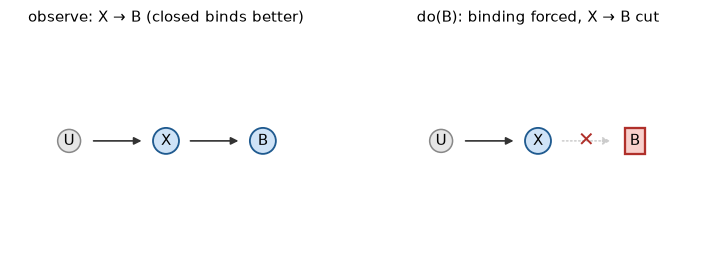

P(closed | bound)      = 0.66   (association)
P(closed | do(bound))  = 0.30   (intervention: binding changes nothing)


In [3]:
fig, axs = plt.subplots(1, 2, figsize=(8, 2.6))
draw_graph(axs[0], {"U": (0, 0, "noise"), "X": (1, 0, "obs"), "B": (2, 0, "obs")},
           [("U", "X"), ("X", "B")], "observe: X → B (closed binds better)")
draw_graph(axs[1], {"U": (0, 0, "noise"), "X": (1, 0, "obs"), "B": (2, 0, "do")},
           [("U", "X"), ("X", "B", "cut")], "do(B): binding forced, X → B cut")
plt.show()

rng = np.random.default_rng(1)
n = 200_000
closed = rng.random(n) < 0.3
bound = rng.random(n) < np.where(closed, 0.9, 0.2)
p_assoc, p_do = closed[bound].mean(), closed.mean()
print(f"P(closed | bound)      = {p_assoc:.2f}   (association)")
print(f"P(closed | do(bound))  = {p_do:.2f}   (intervention: binding changes nothing)")

Seeing bound molecules, most are closed. Forcing every molecule to bind leaves
30 % closed. The ensemble correlation is not the mechanism.

Counterfactuals need more than the arrows. Here are two mechanisms for "ligand T
→ closed Y", with exogenous noise U ~ Bernoulli(½):

* model A: Y = U (the ligand is irrelevant)
* model B: Y = T xor U (the ligand flips the molecule)

Both give p(Y=1 | do(T)) = ½ for either T, so no ensemble experiment, observational
or interventional, can tell them apart. The *twin network* asks about one molecule
seen bound **and** closed. The noise U is shared between the factual world
(T, Y) and the counterfactual world (T\*, Y\*).

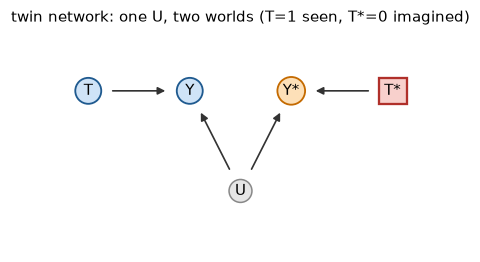

A: Y = U        p(Y|do(T=0))=0.50 p(Y|do(T=1))=0.50   P(Y would be 1 had T=0 | T=1,Y=1) = 1.00
B: Y = T xor U  p(Y|do(T=0))=0.50 p(Y|do(T=1))=0.50   P(Y would be 1 had T=0 | T=1,Y=1) = 0.00


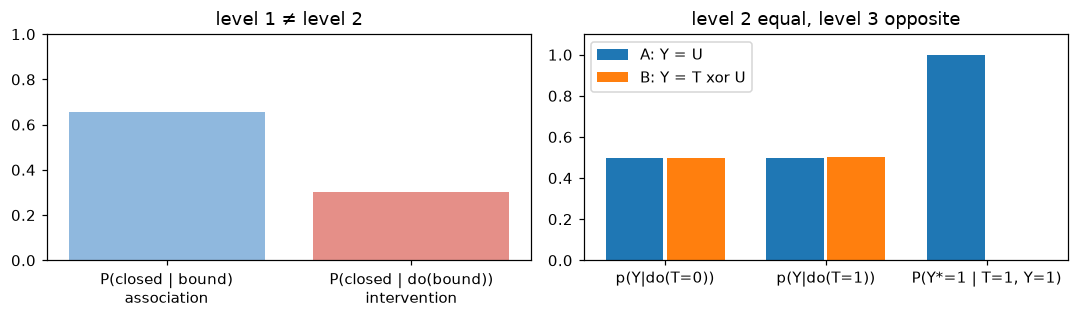

In [4]:
fig, ax = plt.subplots(figsize=(5, 2.6))
draw_graph(ax, {"T": (0, 1, "obs"), "Y": (1, 1, "obs"), "U": (1.5, 0, "noise"),
                "T*": (3, 1, "do"), "Y*": (2, 1, "cf")},
           [("T", "Y"), ("U", "Y"), ("U", "Y*"), ("T*", "Y*")],
           "twin network: one U, two worlds (T=1 seen, T*=0 imagined)")
plt.show()

U = rng.random(n) < 0.5
T = rng.random(n) < 0.5
summary = {}
for name, f in {"A: Y = U": lambda t, u: u, "B: Y = T xor U": lambda t, u: t ^ u}.items():
    Y = f(T, U)
    do0, do1 = f(np.zeros(n, bool), U).mean(), f(np.ones(n, bool), U).mean()
    seen = T & Y                                   # abduction: keep the units we saw
    y_cf = f(np.zeros(n, bool), U)[seen].mean()    # action + prediction, same U
    summary[name] = (do0, do1, y_cf)
    print(f"{name:15s} p(Y|do(T=0))={do0:.2f} p(Y|do(T=1))={do1:.2f}"
          f"   P(Y would be 1 had T=0 | T=1,Y=1) = {y_cf:.2f}")

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 3))
ax0.bar(["P(closed | bound)\nassociation", "P(closed | do(bound))\nintervention"], [p_assoc, p_do],
        color=["#8fb8de", "#e58f88"])
ax0.set_ylim(0, 1); ax0.set_title("level 1 ≠ level 2")
x = np.arange(3)
for k, (name, vals) in enumerate(summary.items()):
    ax1.bar(x + 0.38 * k, vals, width=0.36, label=name)
ax1.set_xticks(x + 0.19, ["p(Y|do(T=0))", "p(Y|do(T=1))", "P(Y*=1 | T=1, Y=1)"])
ax1.set_ylim(0, 1.1); ax1.legend(); ax1.set_title("level 2 equal, level 3 opposite")
fig.tight_layout(); plt.show()

The functional form, meaning how the noise enters, decides the counterfactual. So
a restraint on a counterfactual is a **modelling assumption**: in a factor graph
it is a prior, never a likelihood.

## 2. Is an intermediate FRET efficiency a state, or dynamics? (per burst)

### The experiment

The sample is simulated with tttrlib:
- **Two conformations** with E = 0.2 and 0.8 exchange at 0.3 ms⁻¹ each way,
  about as slowly as molecules cross the focus.
- **Incomplete labelling:** a fifth of the molecules carry only a donor.
- **Background:** 1 kHz in the donor channel and 0.5 kHz in the acceptor
  channel, with a flat micro-time.
- **Detection:** molecules diffuse through a 3D Gaussian focus, with a donor
  and an acceptor detector and micro-times.

As in a real experiment there is also a short **buffer measurement**. Bursts
are found with tttrlib's sliding-window burst search on the exported TTTR stream.

None of the numbers above is handed to the analysis. Both efficiencies, the
donor lifetime τ₀, both exchange rates, the donor-only fraction and both
background rates are **unknowns**, determined from the data in a Bayesian graph
built from IMP.bff objects.

In [5]:
DT, MICRO_NS, BRIGHT = 0.01, 0.008, 400.0   # simulator window (ms), micro-time bin (ns), photons/ms at focus
LASER_NS = 4096 * MICRO_NS                  # micro-time range (ns)
TRUE = {"E_lo": 0.2, "E_hi": 0.8, "tau0": 4.0, "k": 0.3, "bg_D": 1.0, "bg_A": 0.5}

def sim_config(k, population, n_photons, seed):
    E = (TRUE["E_lo"], TRUE["E_hi"])
    species = [{"D": 0.05, "q": [(1 - e) * BRIGHT, e * BRIGHT],          # [donor, acceptor] channel
                "decay": {"lifetimes": [TRUE["tau0"] * (1 - e)], "amplitudes": [1.0], "dt": MICRO_NS}}
               for e in E]
    species.append({"D": 0.05, "q": [BRIGHT, 0.0],                        # donor-only molecules
                    "decay": {"lifetimes": [TRUE["tau0"]], "amplitudes": [1.0], "dt": MICRO_NS}})
    return {
        "settings": {"dt": DT, "n_ph_max": n_photons, "n_channels": 2, "laser_period": LASER_NS,
                     "n_microtime_channels": 4096, "microtime_resolution": MICRO_NS,
                     "active_margin": 1.0, "fast_grid_bbox": True,
                     "seed_diffusion": seed, "seed_emission": seed + 1},
        "box": {"xy": 2.0, "z": 4.0},
        "species": species,
        "k_rad": [0] * 9,
        "k_nrad": [0, k, 0,  k, 0, 0,  0, 0, 0],                           # only lo <-> hi exchange
        "background": [TRUE["bg_D"], TRUE["bg_A"]],                       # photons / ms
        "background_decay": {"pattern": [1.0] * 4096, "dt": MICRO_NS},     # flat micro-time
        "population": population,
        "excitation": {"type": "gaussian3d", "w0": 0.3, "z0": 2.0,
                       "extent_xy": 2.0, "extent_z": 4.0, "spacing": 0.1},
    }

def run_experiment(k, seed=11, n_photons=600_000):
    # The sample measurement: burst-searched TTTR, plus the simulator's ground truth per photon.
    engine = tttrlib.SimEngine.from_dict(sim_config(k, [0.2, 0.2, 0.1], n_photons, seed))
    engine.run()
    ph = engine.photons()
    photon = ph["event_type"] == 0
    data = engine.to_tttr(DT, 2)                    # what the instrument would write
    t_ms = (ph["macro_window"] * DT + ph["arrival_time"])[photon]
    is_acc = ph["channel"][photon] == 1
    micro_ns = ph["micro_time"][photon] * MICRO_NS
    truth = ph["species"][photon]                   # 0 lo, 1 hi, 2 donor-only, 3 background
    molecule = ph["molecule"][photon]
    edges = np.asarray(data.burst_search(L=30, m=10, T=5e-4, mode="sliding_window")).reshape(-1, 2)
    bursts = []
    for s, e in edges:
        sl = slice(int(s), int(e) + 1)
        sig = truth[sl] < 3
        if e - s + 1 < 60 or len(np.unique(molecule[sl][sig])) > 1:
            continue                                # small or coincident bursts
        st = truth[sl][sig]
        bursts.append({"t": t_ms[sl], "acc": is_acc[sl], "micro": micro_ns[sl], "truth": truth[sl],
                       "true_DO": bool(np.mean(st == 2) > 0.5),
                       "dynamic": bool(len(set(st[st < 2])) > 1)})
    return bursts, len(edges)

def run_buffer(seed=99, n_photons=15_000):
    # A buffer-only measurement: no molecules, only background.
    engine = tttrlib.SimEngine.from_dict(sim_config(0.0, [0.0, 0.0, 0.0], n_photons, seed))
    engine.run()
    ph = engine.photons()
    photon = ph["event_type"] == 0
    duration = (ph["macro_window"] * DT + ph["arrival_time"])[photon][-1]
    return duration, [int((ph["channel"][photon] == c).sum()) for c in (0, 1)]

t0 = time.time()
bursts, n_found = run_experiment(TRUE["k"])
T_BUF, N_BUF = run_buffer()
print(f"{n_found} bursts found, {len(bursts)} kept; buffer: {N_BUF} photons in {T_BUF / 1e3:.1f} s "
      f"({time.time() - t0:.1f} s)")
print(f"ground truth (hidden from the analysis): donor-only {np.mean([b['true_DO'] for b in bursts]):.0%}, "
      f"dynamic {np.mean([b['dynamic'] for b in bursts]):.0%}")

1739 bursts found, 1056 kept; buffer: [9960, 5040] photons in 10.0 s (2.8 s)
ground truth (hidden from the analysis): donor-only 17%, dynamic 34%


### The Bayesian graph

Eight unknowns, two datasets, and priors:

| Variable | Role | Prior |
|---|---|---|
| E_lo, E_hi | physics (state efficiencies) | uniform; E_lo < 0.5 < E_hi fixes the labels |
| log₁₀ k₁₂, log₁₀ k₂₁ | kinetics | uniform on [−2, 1.5] |
| τ₀ | calibration | N(4, 0.5) ns, i.e. "about 4 ns", as a dye datasheet would say |
| f_DO | nuisance (labelling) | uniform |
| bg_D, bg_A | nuisance (instrument) | uniform |

The **burst likelihood** treats each burst as either donor-only or a two-state
Markov chain over its photons (the photon-by-photon HMM of H2MM). Each photon
is a mixture of signal and background:
- **Signal:** colour from E_s and donor micro-time from τ₀(1 − E_s).
- **Background:** colour from bg_A / (bg_D + bg_A) and a flat micro-time.

The **buffer likelihood** is Poisson counts in the buffer run, and it reads only
the two background rates.

In IMP.bff the graph has three parts:
- each variable is a `GraphPort`, with bounds and a prior;
- each likelihood is a `GraphNode`, and their sum is the objective of
  `IMP.bff.MCMCSampler`;
- the same structure is declared in an `InferenceFactorGraph`.

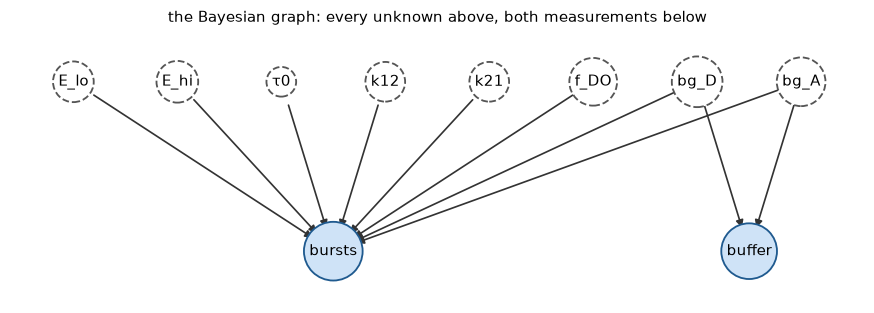

variables      : 8 (8 free numbers)
likelihoods    : 2
priors         : 8
treewidth      : 7
components     : 1
separators     : (none - no shared parameters)



In [6]:
fig, ax = plt.subplots(figsize=(10, 3.2))
draw_graph(ax, {"E_lo": (0, 2, "latent"), "E_hi": (1, 2, "latent"), "τ0": (2, 2, "latent"),
                "k12": (3, 2, "latent"), "k21": (4, 2, "latent"), "f_DO": (5, 2, "latent"),
                "bg_D": (6, 2, "latent"), "bg_A": (7, 2, "latent"),
                "bursts": (2.5, 0, "obs"), "buffer": (6.5, 0, "obs")},
           [(v, "bursts") for v in ("E_lo", "E_hi", "τ0", "k12", "k21", "f_DO", "bg_D", "bg_A")]
           + [("bg_D", "buffer"), ("bg_A", "buffer")],
           "the Bayesian graph: every unknown above, both measurements below")
plt.show()

NAMES = ["E_lo", "E_hi", "tau0", "log10_k12", "log10_k21", "f_DO", "bg_D", "bg_A"]
ROLES = ["physics", "physics", "calibration", "kinetics", "kinetics", "labelling", "instrument", "instrument"]
BOUNDS = [(0.01, 0.5), (0.5, 0.99), (2.0, 6.0), (-2.0, 1.5), (-2.0, 1.5), (0.0, 0.9), (0.0, 5.0), (0.0, 5.0)]
PRIORS = [{"kind": "uniform", "lb": lo, "ub": hi} for lo, hi in BOUNDS]
PRIORS[2] = {"kind": "normal", "mu": 4.0, "sigma": 0.5}
START = [0.3, 0.7, 4.0, 0.0, 0.0, 0.3, 0.5, 0.5]   # a rough start, not the truth

factor_graph = IMP.bff.InferenceFactorGraph()
for i, (name, role) in enumerate(zip(NAMES, ROLES)):
    factor_graph.add_variable(name, name, i, -1, 1, role)
    factor_graph.add_factor(f"prior_{name}", IMP.bff.INFERENCE_FACTOR_PRIOR, [name])
factor_graph.add_factor("bursts", IMP.bff.INFERENCE_FACTOR_LIKELIHOOD, NAMES, 0, len(bursts))
factor_graph.add_factor("buffer", IMP.bff.INFERENCE_FACTOR_LIKELIHOOD, ["bg_D", "bg_A"], 1, 2)
print(factor_graph.describe())

In [7]:
CAP = 150                                           # photons per burst used in the likelihood

def pad_bursts(bs):
    # the bursts as padded arrays, so the forward algorithm runs over all bursts at once
    n, L = len(bs), min(CAP, max(len(b["t"]) for b in bs))
    arr = {"acc": np.zeros((n, L), bool), "micro": np.zeros((n, L)), "dt": np.zeros((n, L)),
           "mask": np.zeros((n, L), bool), "rate": np.zeros(n)}
    for i, b in enumerate(bs):
        m = min(len(b["t"]), CAP)
        arr["acc"][i, :m], arr["micro"][i, :m], arr["mask"][i, :m] = b["acc"][:m], b["micro"][:m], True
        arr["dt"][i, 1:m] = np.diff(b["t"][:m])
        arr["rate"][i] = len(b["t"]) / (b["t"][-1] - b["t"][0])   # photons / ms
    return arr

def emissions(p, acc, micro, rate):
    # per photon: (donor-only, state lo, state hi) densities, signal mixed with background
    E_lo, E_hi, tau0, _, _, _, bg_D, bg_A = p
    f = np.clip((bg_D + bg_A) / rate, 0.0, 0.99)
    if np.ndim(f):
        f = f[:, None]
    bg = np.where(acc, bg_A / (bg_D + bg_A), bg_D / (bg_D + bg_A) / LASER_NS)
    def signal(E):
        tau = tau0 * (1 - E)
        return np.where(acc, E, (1 - E) / tau * np.exp(-micro / tau))
    return [(1 - f) * signal(E) + f * bg for E in (0.0, E_lo, E_hi)], f, bg

def burst_log_likelihoods(p, arr):
    # log p(burst | donor-only) and log p(burst | two-state chain), forward algorithm
    k12, k21 = 10 ** p[3], 10 ** p[4]
    (e_do, e_lo, e_hi), _, _ = emissions(p, arr["acc"], arr["micro"], arr["rate"])
    e = np.stack([e_lo, e_hi], -1)
    e[~arr["mask"]] = 1.0
    e_do = np.where(arr["mask"], e_do, 1.0)
    pi = np.array([k21, k12]) / (k12 + k21)
    decay = np.exp(-(k12 + k21) * arr["dt"])
    alpha = pi * e[:, 0]
    c = alpha.sum(1); ll = np.log(c); alpha /= c[:, None]
    for j in range(1, e.shape[1]):
        d = decay[:, j, None]
        a = (pi * (1 - d) + alpha * d) * e[:, j]    # alpha @ (pi + (I - pi) d)
        c = a.sum(1); ll += np.log(c); alpha = a / c[:, None]
    return np.log(e_do).sum(1), ll

class BurstLikelihood(IMP.bff.GraphNode):
    # log-likelihood of all bursts; inputs are the eight parameter ports
    def evaluate(self):
        p = [self.get_input_port(n).get_value() for n in NAMES]
        with np.errstate(all="ignore"):
            l_do, l_da = burst_log_likelihoods(p, self.arr)
            ll = np.logaddexp(np.log(p[5]) + l_do, np.log1p(-p[5]) + l_da).sum()
        self.get_output_port("lnL").set_value(float(ll) if np.isfinite(ll) else -1e300)

class BufferLikelihood(IMP.bff.GraphNode):
    # Poisson counts of the buffer run; inputs are the two background ports
    def evaluate(self):
        ll = 0.0
        for n_counts, name in zip(N_BUF, ("bg_D", "bg_A")):
            lam = max(self.get_input_port(name).get_value() * T_BUF, 1e-300)
            ll += n_counts * np.log(lam) - lam
        self.get_output_port("lnL").set_value(float(ll))

KEEP_ALIVE = []                                      # nodes are held weakly by downstream ports

def build_posterior(bs):
    ports = {}
    for name, (lo, hi), prior, x0 in zip(NAMES, BOUNDS, PRIORS, START):
        p = IMP.bff.GraphPort(value=float(x0), name=name)
        p.set_bounds(lo, hi); p.set_is_bounded(True)  # bounds before the flag, or the value is clamped
        p.set_prior(json.dumps(prior)); p.set_value(float(x0))
        ports[name] = p
    burst_node = BurstLikelihood("bursts"); burst_node.arr = pad_bursts(bs)
    for name in NAMES:
        burst_node.add_input_port(name, ports[name])
    burst_node.add_output_port("lnL", IMP.bff.GraphPort(0.0, False, True))
    buffer_node = BufferLikelihood("buffer")
    for name in ("bg_D", "bg_A"):
        buffer_node.add_input_port(name, ports[name])
    buffer_node.add_output_port("lnL", IMP.bff.GraphPort(0.0, False, True))
    total = IMP.bff.GraphNode("total")
    for key, node in (("a", burst_node), ("b", buffer_node)):
        q = IMP.bff.GraphPort(0.0); q.set_link(node.get_output_port("lnL")); total.add_input_port(key, q)
    total.add_output_port("total", IMP.bff.GraphPort(0.0, False, True))
    total.set_callback("addition_double", "C")
    KEEP_ALIVE.extend([burst_node, buffer_node, total])
    return ports, total

def sample_posterior(bs, n_steps=400, seed=3, start=None):
    ports, total = build_posterior(bs)
    sampler = IMP.bff.MCMCSampler("de", seed)        # differential evolution, ter Braak
    sampler.set_parameter_ports([ports[n] for n in NAMES])
    sampler.set_objective(total, "total")
    sampler.set_output_is_log_likelihood(True)
    if start is not None:
        sampler.set_initial_values(list(map(float, start)))
    sampler.run(n_steps)
    chain = np.asarray(sampler.get_chain_flat()).reshape(n_steps, -1, len(NAMES))
    return sampler, chain

rng = np.random.default_rng(2)
fit_bursts = [bursts[i] for i in rng.permutation(len(bursts))[:500]]
t0 = time.time()
sampler, chain = sample_posterior(fit_bursts)
posterior = chain[chain.shape[0] // 2:].reshape(-1, len(NAMES))    # second half
print(sampler.describe())
print(f"{sampler.get_number_of_evaluations()} evaluations in {time.time() - t0:.0f} s")
truth_vec = [TRUE["E_lo"], TRUE["E_hi"], TRUE["tau0"], np.log10(TRUE["k"]), np.log10(TRUE["k"]),
             np.mean([b["true_DO"] for b in fit_bursts]), TRUE["bg_D"], TRUE["bg_A"]]
for name, mu, sd, tv in zip(NAMES, posterior.mean(0), posterior.std(0), truth_vec):
    print(f"  {name:10s} {mu:7.3f} ± {sd:.3f}   (truth {tv:.3f})")

MCMCSampler(algorithm='de', n_parameters=8, n_walkers=16, iteration=400, acceptance_rate=0.222656)
8016 evaluations in 55 s
  E_lo         0.204 ± 0.003   (truth 0.200)
  E_hi         0.803 ± 0.002   (truth 0.800)
  tau0         3.991 ± 0.025   (truth 4.000)
  log10_k12   -0.422 ± 0.039   (truth -0.523)
  log10_k21   -0.415 ± 0.037   (truth -0.523)
  f_DO         0.173 ± 0.017   (truth 0.178)
  bg_D         1.001 ± 0.010   (truth 1.000)
  bg_A         0.505 ± 0.007   (truth 0.500)


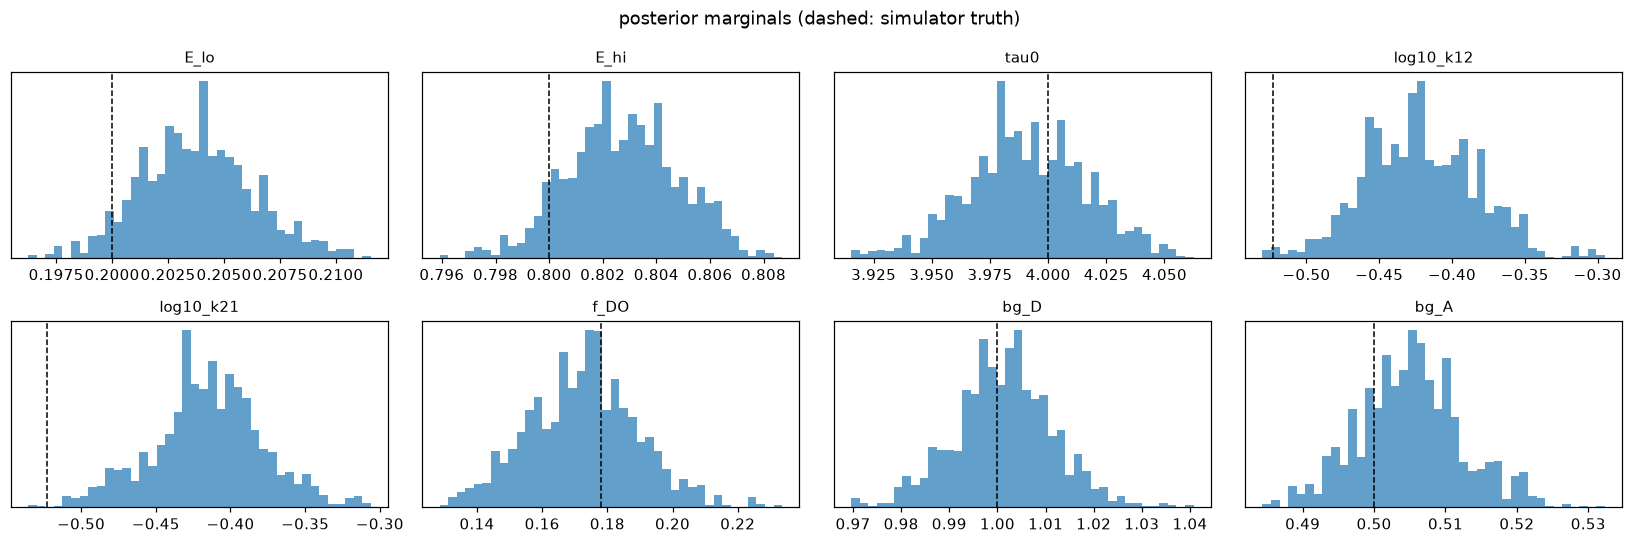

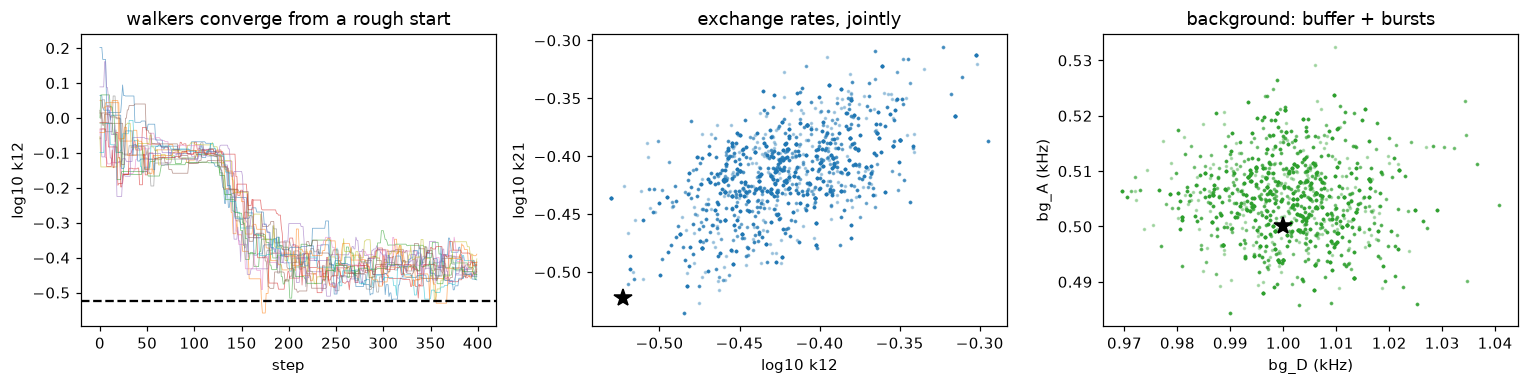

In [8]:
fig, axs = plt.subplots(2, 4, figsize=(15, 5))
for i, ax in enumerate(axs.flat):
    ax.hist(posterior[:, i], 40, color="C0", alpha=0.7, density=True)
    ax.axvline(truth_vec[i], color="k", ls="--", lw=1)
    ax.set_title(NAMES[i], fontsize=10); ax.set_yticks([])
fig.suptitle("posterior marginals (dashed: simulator truth)"); fig.tight_layout(); plt.show()

fig, axs = plt.subplots(1, 3, figsize=(14, 3.6))
for w in range(chain.shape[1]):
    axs[0].plot(chain[:, w, 3], lw=0.5, alpha=0.6)
axs[0].axhline(np.log10(TRUE["k"]), color="k", ls="--"); axs[0].set_xlabel("step"); axs[0].set_ylabel("log10 k12")
axs[0].set_title("walkers converge from a rough start")
axs[1].scatter(posterior[:, 3], posterior[:, 4], s=2, alpha=0.3)
axs[1].plot(np.log10(TRUE["k"]), np.log10(TRUE["k"]), "k*", ms=12)
axs[1].set_xlabel("log10 k12"); axs[1].set_ylabel("log10 k21"); axs[1].set_title("exchange rates, jointly")
axs[2].scatter(posterior[:, 6], posterior[:, 7], s=2, alpha=0.3, c="C2")
axs[2].plot(TRUE["bg_D"], TRUE["bg_A"], "k*", ms=12)
axs[2].set_xlabel("bg_D (kHz)"); axs[2].set_ylabel("bg_A (kHz)"); axs[2].set_title("background: buffer + bursts")
fig.tight_layout(); plt.show()

### The counterfactual, on top of the posterior

**The static FRET line is already a counterfactual.** It is the E–⟨τ⟩_f a
molecule would show *if it did not change during the burst*, i.e. under
do(k = 0). As a twin network it becomes a statement about each burst. The
computation is repeated for posterior draws of the eight parameters, so their
uncertainty carries through.

1. **Abduction.** From the burst's photons:
   - sample donor-only or not;
   - sample the state path by forward-filtering, backward-sampling over the
     photon arrivals;
   - sample each photon's background-or-signal label;
   - sample its colour and micro-time uniforms.
2. **Action.** Set do(k = 0): the molecule stays in the state it started the
   burst in.
3. **Prediction.** Background photons stay as they were, and signal photons are
   re-emitted with the same uniforms in the frozen state.

Donor-only bursts are static by construction. The causal graph of one burst,
with its twin:

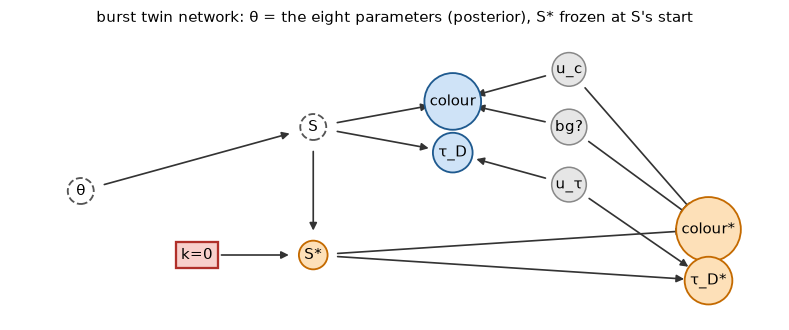

In [9]:
fig, ax = plt.subplots(figsize=(9, 3.4))
draw_graph(ax, {"θ": (-1, 1, "latent"), "S": (1, 2, "latent"), "colour": (2.2, 2.4, "obs"), "τ_D": (2.2, 1.6, "obs"),
                "u_c": (3.2, 2.9, "noise"), "u_τ": (3.2, 1.1, "noise"), "bg?": (3.2, 2.0, "noise"),
                "k=0": (0, 0, "do"), "S*": (1, 0, "cf"), "colour*": (4.4, 0.4, "cf"), "τ_D*": (4.4, -0.4, "cf")},
           [("θ", "S"), ("S", "colour"), ("S", "τ_D"), ("u_c", "colour"), ("u_τ", "τ_D"), ("bg?", "colour"),
            ("k=0", "S*"), ("S", "S*"), ("S*", "colour*"), ("S*", "τ_D*"), ("bg?", "colour*"),
            ("u_c", "colour*"), ("u_τ", "τ_D*")],
           "burst twin network: θ = the eight parameters (posterior), S* frozen at S's start")
plt.show()

In [10]:
def abduct_burst(b, draws, n_paths, rng):
    # posterior over (donor-only?, state path, background labels) for one burst, and its frozen twin
    t, acc, micro = b["t"], b["acc"], b["micro"]
    N, D = len(t), len(draws)
    rate = N / (t[-1] - t[0])
    E = draws[:, [0, 1]]                                   # (D, 2)
    tau = draws[:, 2:3] * (1 - E)
    k12, k21 = 10 ** draws[:, 3], 10 ** draws[:, 4]
    f = np.clip((draws[:, 6] + draws[:, 7]) / rate, 0, 0.99)[:, None]
    bgA = (draws[:, 7] / (draws[:, 6] + draws[:, 7]))[:, None]
    bg = np.where(acc[None, :], bgA, (1 - bgA) / LASER_NS)                       # (D, N)
    sig = np.stack([np.where(acc[None, :], E[:, s:s + 1],
                             (1 - E[:, s:s + 1]) / tau[:, s:s + 1] * np.exp(-micro[None, :] / tau[:, s:s + 1]))
                    for s in (0, 1)], -1)                                         # (D, N, 2)
    e = (1 - f)[..., None] * sig + (f * bg)[..., None]
    sig_do = np.where(acc[None, :], 0.0, np.exp(-micro[None, :] / draws[:, 2:3]) / draws[:, 2:3])
    l_do = np.log((1 - f) * sig_do + f * bg).sum(1)
    pi = np.stack([k21, k12], 1) / (k12 + k21)[:, None]                          # (D, 2)
    decay = np.exp(-(k12 + k21)[:, None] * np.diff(t)[None, :])                  # (D, N-1)
    alpha = np.empty((D, N, 2)); a = pi * e[:, 0]; c = a.sum(1); l_da = np.log(c); alpha[:, 0] = a / c[:, None]
    for j in range(1, N):
        d = decay[:, j - 1, None]
        a = (pi * (1 - d) + alpha[:, j - 1] * d) * e[:, j]
        c = a.sum(1); l_da += np.log(c); alpha[:, j] = a / c[:, None]
    p_do = 1 / (1 + np.exp(np.log1p(-draws[:, 5]) + l_da - np.log(draws[:, 5]) - l_do))   # (D,)
    # backward sampling, n_paths per draw
    S = np.empty((D, n_paths, N), int)
    S[:, :, -1] = rng.random((D, n_paths)) < alpha[:, -1, 1:2]
    for j in range(N - 2, -1, -1):
        d = decay[:, j, None]; nxt = S[:, :, j + 1]
        pn = np.take_along_axis(pi, nxt, 1)
        w0 = alpha[:, j, 0:1] * (pn * (1 - d) + (nxt == 0) * d)
        w1 = alpha[:, j, 1:2] * (pn * (1 - d) + (nxt == 1) * d)
        S[:, :, j] = rng.random((D, n_paths)) < w1 / (w0 + w1)
    is_do = rng.random((D, n_paths)) < p_do[:, None]
    switched = (S != S[:, :, :1]).any(2) & ~is_do
    # twin: background labels, colour and micro-time uniforms, then frozen re-emission
    Ed = np.take_along_axis(np.broadcast_to(E[:, None, :], (D, n_paths, 2)), S, 2)        # (D, P, N)
    taud = np.take_along_axis(np.broadcast_to(tau[:, None, :], (D, n_paths, 2)), S, 2)
    sig_path = np.take_along_axis(np.broadcast_to(sig[:, None], (D, n_paths, N, 2)), S[..., None], 3)[..., 0]
    resp_bg = (f * bg)[:, None] / ((1 - f)[:, None] * sig_path + (f * bg)[:, None])
    is_bg = rng.random(S.shape) < resp_bg
    u = rng.random(S.shape)
    u_c = np.where(acc, u * Ed, Ed + u * (1 - Ed))
    u_t = np.where(acc, rng.random(S.shape), np.exp(-micro / taud))
    s0 = S[:, :, :1]
    E0 = np.take_along_axis(np.broadcast_to(E[:, None, :], (D, n_paths, 2)), s0, 2)
    tau0_ = np.take_along_axis(np.broadcast_to(tau[:, None, :], (D, n_paths, 2)), s0, 2)
    acc_cf = np.where(is_bg, acc, u_c < E0)
    micro_cf = np.where(is_bg, micro, -tau0_ * np.log(u_t))
    E_cf = acc_cf.mean(2)
    tau_cf = np.nanmean(np.where(acc_cf, np.nan, micro_cf), 2)
    E_meas, tau_meas = acc.mean(), micro[~acc].mean()
    E_cf = np.where(is_do, E_meas, E_cf); tau_cf = np.where(is_do, tau_meas, tau_cf)   # donor-only: unchanged
    return {"p_dynamic": switched.mean(), "p_DO": p_do.mean(),
            "p_high": np.where(is_do[..., None], np.nan, S).reshape(-1, N),
            "E": E_meas, "tau": tau_meas, "E_cf": np.nanmean(E_cf), "tau_cf": np.nanmean(tau_cf),
            "E_cf_draw": E_cf.ravel()[0], "tau_cf_draw": tau_cf.ravel()[0]}

def abduct_all(bs, post, rng, n_draws=20, n_paths=10):
    draws = post[rng.choice(len(post), n_draws, replace=False)]
    for b in bs:
        with np.errstate(all="ignore"):
            r = abduct_burst(b, draws, n_paths, rng)
        r["p_high"] = np.nanmean(r["p_high"], 0)
        b.update(r)
    truth = np.array([b["dynamic"] for b in bs])
    p_dyn = np.array([b["p_dynamic"] for b in bs])
    return truth, p_dyn

t0 = time.time()
truth, p_dyn = abduct_all(bursts, posterior, np.random.default_rng(4))
p_do = np.array([b["p_DO"] for b in bursts]); true_do = np.array([b["true_DO"] for b in bursts])
print(f"abduction for {len(bursts)} bursts x 200 (parameter draw, path) pairs: {time.time() - t0:.1f} s")
print(f"donor-only bursts identified: {((p_do > 0.5) == true_do).mean():.0%}")
print(f"mean P(dynamic): truly dynamic {p_dyn[truth].mean():.2f}, truly static {p_dyn[~truth].mean():.2f}; "
      f"classified correctly at 0.5: {((p_dyn > 0.5) == truth).mean():.0%}")

/var/folders/cl/txwq_hq52rl_t0f9xjk3g5c00000gn/T/ipykernel_35609/3417712851.py:65: RuntimeWarning: Mean of empty slice
  r["p_high"] = np.nanmean(r["p_high"], 0)


abduction for 1056 bursts x 200 (parameter draw, path) pairs: 9.3 s
donor-only bursts identified: 100%
mean P(dynamic): truly dynamic 0.92, truly static 0.14; classified correctly at 0.5: 92%


### Anatomy of one dynamic burst

Before looking at the population, look at one burst. The three panels, top to
bottom:

1. Each photon by colour, at its arrival time. Grey crosses are photons the
   simulator generated as background; the analysis is not told which.
2. The donor micro-times: short in the high-E state, long in the low-E state.
3. What the abduction concludes about the state path, against the simulator's
   true path.

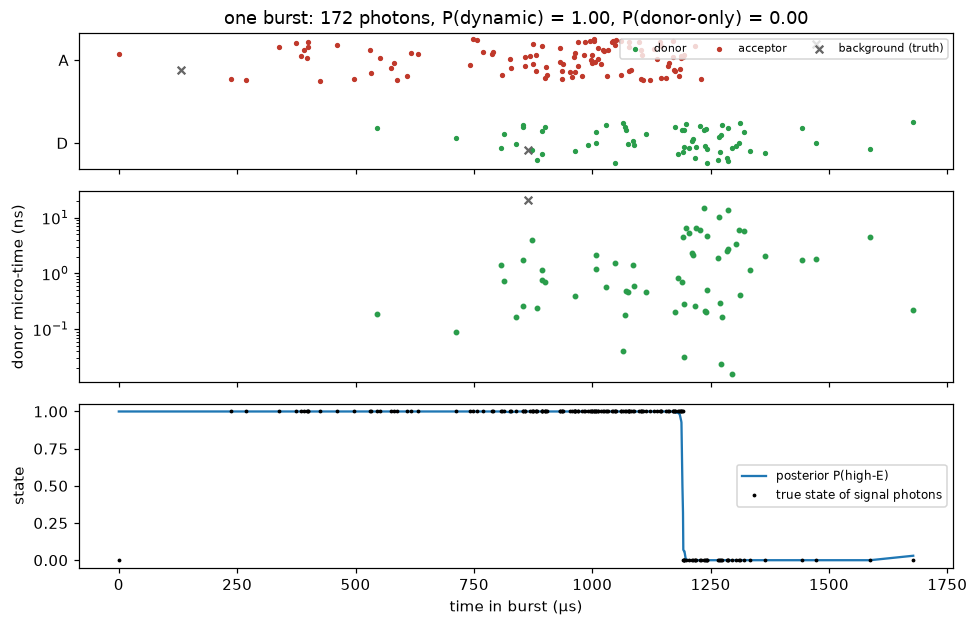

In [11]:
cand = [i for i, b in enumerate(bursts) if b["p_dynamic"] > 0.95 and 100 < len(b["t"]) < 250]
b = bursts[cand[0]]
t = (b["t"] - b["t"][0]) * 1e3                       # µs
is_bg = b["truth"] == 3
fig, axs = plt.subplots(3, 1, figsize=(9, 5.8), sharex=True, gridspec_kw={"height_ratios": [1, 1.4, 1.2]})
jit = np.random.default_rng(0).uniform(-0.25, 0.25, len(t))
for sel, y, col, lab in ((~b["acc"] & ~is_bg, 0, "#2a9d4b", "donor"), (b["acc"] & ~is_bg, 1, "#c0392b", "acceptor")):
    axs[0].scatter(t[sel], y + jit[sel], s=6, c=col, label=lab)
axs[0].scatter(t[is_bg], b["acc"][is_bg] + jit[is_bg], s=25, marker="x", c="0.4", label="background (truth)")
axs[0].set_yticks([0, 1], ["D", "A"]); axs[0].legend(fontsize=7, loc="upper right", ncol=3)
axs[0].set_title(f"one burst: {len(t)} photons, P(dynamic) = {b['p_dynamic']:.2f}, P(donor-only) = {b['p_DO']:.2f}")
d = ~b["acc"]
axs[1].scatter(t[d & ~is_bg], b["micro"][d & ~is_bg], s=8, c="#2a9d4b")
axs[1].scatter(t[d & is_bg], b["micro"][d & is_bg], s=25, marker="x", c="0.4")
axs[1].set_yscale("log"); axs[1].set_ylabel("donor micro-time (ns)")
axs[2].plot(t, b["p_high"], color="C0", label="posterior P(high-E)")
true_path = np.where(is_bg, np.nan, b["truth"]).astype(float)
axs[2].plot(t, true_path, "k.", ms=3, label="true state of signal photons")
axs[2].set_ylabel("state"); axs[2].set_xlabel("time in burst (µs)"); axs[2].legend(loc="center right", fontsize=8)
fig.tight_layout(); plt.show()

### The population, and each burst's frozen twin

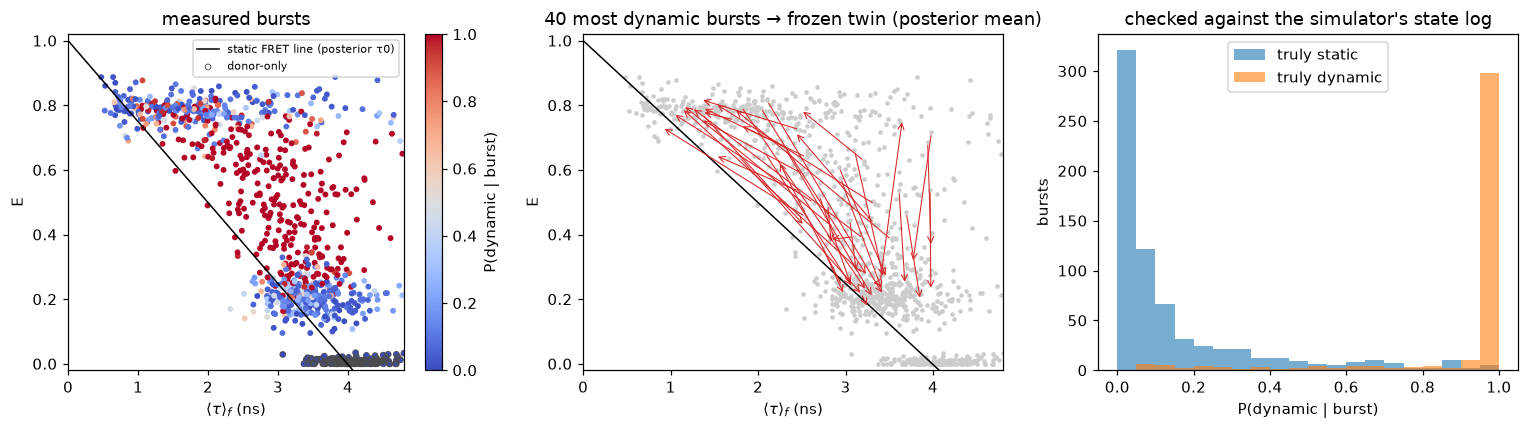

In [12]:
E = np.array([b["E"] for b in bursts]); tau = np.array([b["tau"] for b in bursts])
E_cf = np.array([b["E_cf"] for b in bursts]); tau_cf = np.array([b["tau_cf"] for b in bursts])
E_draw = np.array([b["E_cf_draw"] for b in bursts])
tau0_post = posterior[:, 2].mean()

fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(14, 4))
x = np.linspace(0, 4.5, 50)
for ax in (ax0, ax1):
    ax.plot(x, 1 - x / tau0_post, "k-", lw=1, label="static FRET line (posterior τ0)")
    ax.set_xlabel(r"$\langle\tau\rangle_f$ (ns)"); ax.set_ylabel("E"); ax.set_xlim(0, 4.8); ax.set_ylim(-0.02, 1.02)
sc = ax0.scatter(tau, E, c=p_dyn, s=8, cmap="coolwarm", vmin=0, vmax=1)
ax0.scatter(tau[p_do > 0.5], E[p_do > 0.5], s=14, facecolors="none", edgecolors="0.3", lw=0.6, label="donor-only")
fig.colorbar(sc, ax=ax0, label="P(dynamic | burst)"); ax0.legend(fontsize=7, loc="upper right")
ax0.set_title("measured bursts")
pick = np.argsort(-p_dyn)[:40]
ax1.scatter(tau, E, s=4, c="0.8")
for i in pick:
    ax1.annotate("", (tau_cf[i], E_cf[i]), (tau[i], E[i]), arrowprops=dict(arrowstyle="->", color="C3", lw=0.7))
ax1.set_title("40 most dynamic bursts → frozen twin (posterior mean)")
bins = np.linspace(0, 1, 21)
ax2.hist(p_dyn[~truth], bins, alpha=0.6, label="truly static")
ax2.hist(p_dyn[truth], bins, alpha=0.6, label="truly dynamic")
ax2.set_xlabel("P(dynamic | burst)"); ax2.set_ylabel("bursts"); ax2.legend()
ax2.set_title("checked against the simulator's state log")
fig.tight_layout(); plt.show()

Each arrow ends where the burst *would have been* without exchange: at the
state it started in. Arrows that stop between the states belong to bursts whose
starting state is itself uncertain (the posterior mean averages them).
Background photons keep every point a little off the ideal line, and they stay
in the twin too. A single posterior draw always lands on a state:

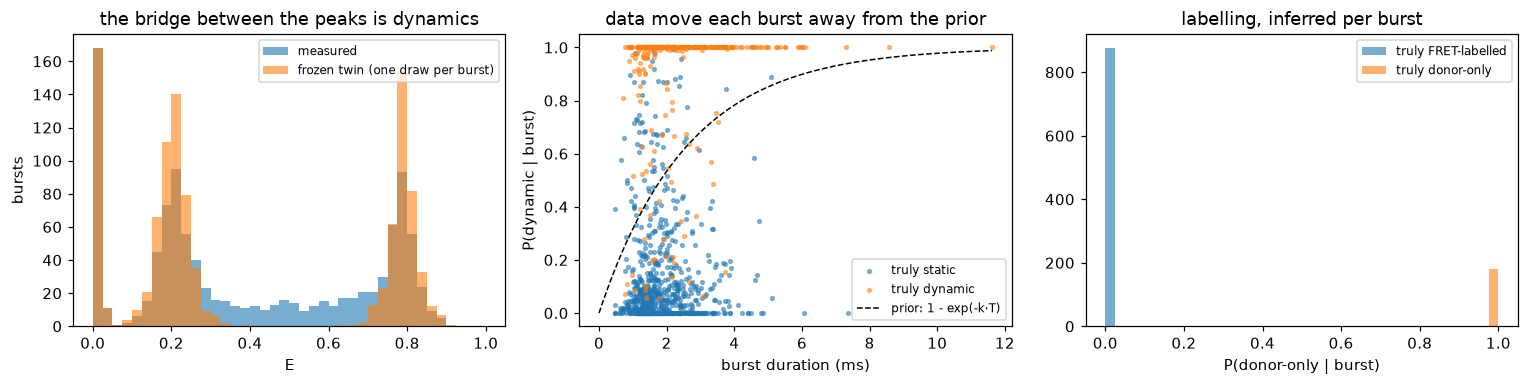

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(14, 3.6))
bins = np.linspace(0, 1, 41)
axs[0].hist(E, bins, alpha=0.6, label="measured")
axs[0].hist(E_draw, bins, alpha=0.6, label="frozen twin (one draw per burst)")
axs[0].set_xlabel("E"); axs[0].set_ylabel("bursts"); axs[0].legend(fontsize=8)
axs[0].set_title("the bridge between the peaks is dynamics")
duration = np.array([b["t"][-1] - b["t"][0] for b in bursts])
k_post = 10 ** posterior[:, 3:5].mean(0)
axs[1].scatter(duration[~truth], p_dyn[~truth], s=6, alpha=0.5, label="truly static")
axs[1].scatter(duration[truth], p_dyn[truth], s=6, alpha=0.5, label="truly dynamic")
dd = np.linspace(0, duration.max(), 100)
axs[1].plot(dd, 1 - np.exp(-k_post.mean() * dd), "k--", lw=1, label="prior: 1 - exp(-k·T)")
axs[1].set_xlabel("burst duration (ms)"); axs[1].set_ylabel("P(dynamic | burst)"); axs[1].legend(fontsize=8)
axs[1].set_title("data move each burst away from the prior")
axs[2].hist(p_do[~true_do], bins, alpha=0.6, label="truly FRET-labelled")
axs[2].hist(p_do[true_do], bins, alpha=0.6, label="truly donor-only")
axs[2].set_xlabel("P(donor-only | burst)"); axs[2].legend(fontsize=8)
axs[2].set_title("labelling, inferred per burst")
fig.tight_layout(); plt.show()

### How fast can the exchange be?

The whole pipeline is repeated at two more exchange rates: simulate, sample the
posterior, abduct. Slow exchange leaves most bursts static; fast exchange makes
nearly all of them dynamic. Do the rates, and the per-burst calls, stay right?

/var/folders/cl/txwq_hq52rl_t0f9xjk3g5c00000gn/T/ipykernel_35609/3417712851.py:65: RuntimeWarning: Mean of empty slice
  r["p_high"] = np.nanmean(r["p_high"], 0)


sweep: 77 s
k =  0.1 ms^-1: 949 bursts, k12 = 0.15, k21 = 0.15, truly dynamic 14%, mean P(dynamic) 19%, correct 94%
k =  0.3 ms^-1: 1056 bursts, k12 = 0.38, k21 = 0.38, truly dynamic 34%, mean P(dynamic) 41%, correct 92%
k =  1.0 ms^-1: 982 bursts, k12 = 0.93, k21 = 1.17, truly dynamic 63%, mean P(dynamic) 66%, correct 94%


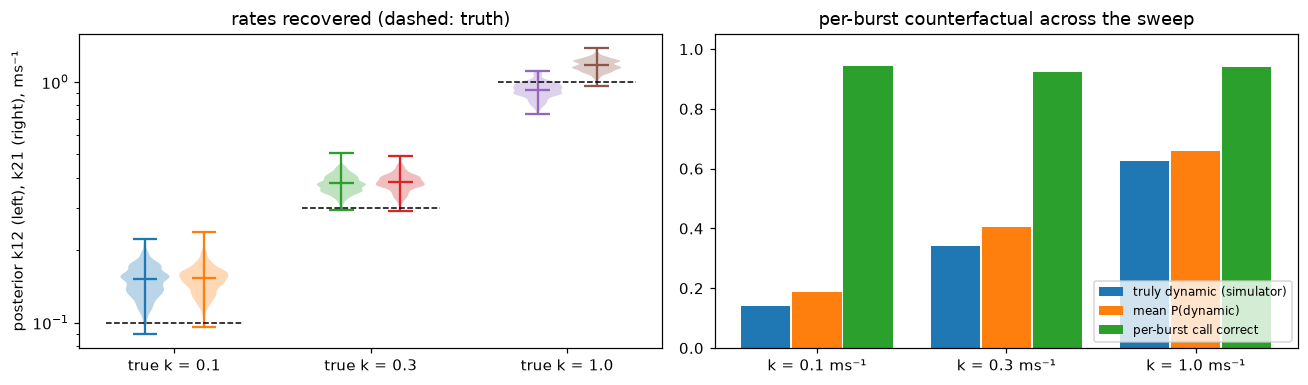

In [14]:
sweep = {TRUE["k"]: (posterior, truth, p_dyn, len(bursts))}
t0 = time.time()
for k in (0.1, 1.0):
    bs, _ = run_experiment(k, seed=21)
    sub = [bs[i] for i in np.random.default_rng(5).permutation(len(bs))[:400]]
    _, ch = sample_posterior(sub, n_steps=250, seed=7, start=posterior.mean(0))
    post_k = ch[125:].reshape(-1, len(NAMES))
    tr, pd = abduct_all(bs, post_k, np.random.default_rng(6), n_draws=10, n_paths=10)
    sweep[k] = (post_k, tr, pd, len(bs))
print(f"sweep: {time.time() - t0:.0f} s")
ks = sorted(sweep)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 3.6))
for i, k in enumerate(ks):
    post_k, tr, pd, nb = sweep[k]
    lk = np.log10(10 ** post_k[:, 3:5]).mean(1)
    ax0.violinplot(10 ** post_k[:, 3], [i - 0.15], widths=0.25, showmeans=True)
    ax0.violinplot(10 ** post_k[:, 4], [i + 0.15], widths=0.25, showmeans=True)
    ax0.plot([i - 0.35, i + 0.35], [k, k], "k--", lw=1)
    print(f"k = {k:4.1f} ms^-1: {nb} bursts, k12 = {10 ** post_k[:, 3].mean():.2f}, k21 = {10 ** post_k[:, 4].mean():.2f}, "
          f"truly dynamic {tr.mean():.0%}, mean P(dynamic) {pd.mean():.0%}, correct {((pd > 0.5) == tr).mean():.0%}")
ax0.set_yscale("log"); ax0.set_xticks(range(len(ks)), [f"true k = {k}" for k in ks])
ax0.set_ylabel("posterior k12 (left), k21 (right), ms⁻¹"); ax0.set_title("rates recovered (dashed: truth)")
xk = np.arange(len(ks))
ax1.bar(xk - 0.27, [sweep[k][1].mean() for k in ks], 0.26, label="truly dynamic (simulator)")
ax1.bar(xk, [sweep[k][2].mean() for k in ks], 0.26, label="mean P(dynamic)")
ax1.bar(xk + 0.27, [((sweep[k][2] > 0.5) == sweep[k][1]).mean() for k in ks], 0.26, label="per-burst call correct")
ax1.set_xticks(xk, [f"k = {k} ms⁻¹" for k in ks]); ax1.set_ylim(0, 1.05); ax1.legend(fontsize=8, loc="lower right")
ax1.set_title("per-burst counterfactual across the sweep")
fig.tight_layout(); plt.show()

What this still assumes is stated in the model:
- Markov exchange between two states;
- single-exponential donor decays, with no IRF and no crosstalk;
- γ = 1;
- a background fraction per burst taken from the burst's mean count rate;
- at most 150 photons per burst in the likelihood.

Each is a node or a variable that can be added to the graph. The model is part
of the result.

One discrepancy remains open. The exchange rates come out about 25 % high
(0.38 against 0.30 ms⁻¹, roughly 2.5 posterior standard deviations), while
every other parameter matches. Candidates are the per-burst background
fraction taken from the mean count rate, burst-search selection, and the
150-photon cap. It is not yet diagnosed, and the per-burst counterfactuals
above inherit it.

## 3. Allostery: which path carries the signal? (mediation)

An effector L binds site 1. FRET pair 1 reads the **hinge** distance M, pair 2 the
**active-site** distance Y. L acts on Y through the hinge (L → M → Y) and
possibly directly (L → Y). A latent W, a fluctuation that moves both hinge and
active site, may be present.

The *natural indirect effect* (NIE) asks what the active site would do with the
effector bound but the hinge left where it would have been without it,
Y(L=1, M(L=0)). That mixes two worlds for one molecule, so it is a
counterfactual by definition (Pearl 2001).

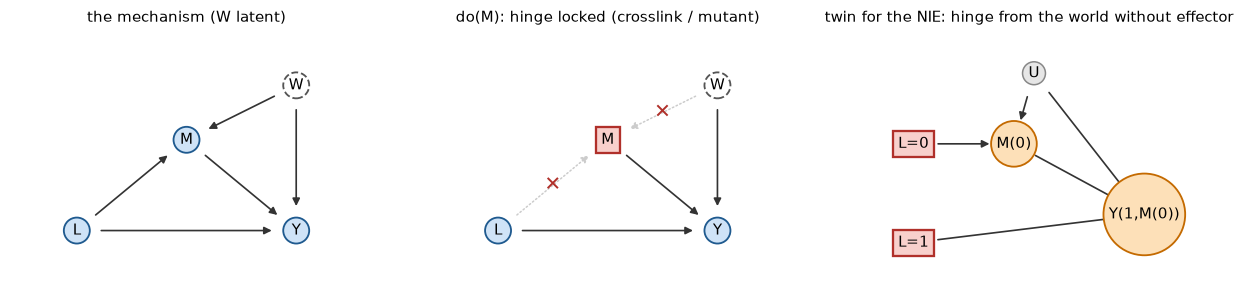

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(14, 3))
base = {"L": (0, 0, "obs"), "M": (1, 1, "obs"), "Y": (2, 0, "obs"), "W": (2, 1.6, "latent")}
draw_graph(axs[0], base, [("L", "M"), ("M", "Y"), ("L", "Y"), ("W", "M"), ("W", "Y")],
           "the mechanism (W latent)")
draw_graph(axs[1], {**base, "M": (1, 1, "do")}, [("L", "M", "cut"), ("W", "M", "cut"), ("M", "Y"), ("L", "Y"), ("W", "Y")],
           "do(M): hinge locked (crosslink / mutant)")
draw_graph(axs[2], {"L=0": (0, 1, "do"), "M(0)": (1, 1, "cf"), "L=1": (0, -0.4, "do"), "Y(1,M(0))": (2.3, 0, "cf"),
                    "U": (1.2, 2, "noise")},
           [("L=0", "M(0)"), ("M(0)", "Y(1,M(0))"), ("L=1", "Y(1,M(0))"), ("U", "M(0)"), ("U", "Y(1,M(0))")],
           "twin for the NIE: hinge from the world without effector")
plt.show()

The structural model is linear in Å, with true NIE = a·b = 0.80 Å and
NDE = c = 0.30 Å.

In [16]:
a, b_, c = 1.0, 0.8, 0.3        # L->M, M->Y, L->Y (Å)
g = 1.0                         # W->M

def world(L, rng, n, h, W=None, UM=None, UY=None, M=None):
    W = rng.normal(size=n) if W is None else W
    UM = rng.normal(scale=0.5, size=n) if UM is None else UM
    UY = rng.normal(scale=0.5, size=n) if UY is None else UY
    gw = g if h != 0 else 0.0
    M = a * L + gw * W + UM if M is None else M
    Y = c * L + b_ * M + h * W + UY
    return W, UM, UY, M, Y

def experiment(h, rng, n=100_000):
    # the definition, by twin simulation: same W, U_M, U_Y in every world
    W, UM, UY, M0, Y00 = world(0, rng, n, h)
    *_, M1, Y11 = world(1, rng, n, h, W, UM, UY)
    *_, Y1M0 = world(1, rng, n, h, W, UM, UY, M=M0)
    out = {"twin NIE": (Y11 - Y1M0).mean(), "twin NDE": (Y1M0 - Y00).mean()}
    # A: pairs on separate molecules -> only E[M|L] and E[Y|L]
    L = rng.integers(2, size=n).astype(float)
    W, UM, UY, M, Y = world(L, rng, n, h)
    out["A total"] = Y[L == 1].mean() - Y[L == 0].mean()
    a_hat = M[L == 1].mean() - M[L == 0].mean()
    # B: both pairs on the same molecule -> regress Y on (L, M)
    out["B NIE"] = a_hat * np.linalg.lstsq(np.c_[np.ones(n), L, M], Y, rcond=None)[0][2]
    # C: hinge locked at set distances = do(M)
    m_set = rng.choice([-1.0, 0.0, 1.0, 2.0], size=n)
    *_, Yd = world(L, rng, n, h, M=m_set)
    out["C NIE"] = a_hat * np.linalg.lstsq(np.c_[np.ones(n), L, m_set], Yd, rcond=None)[0][2]
    out["data"] = (L[:3000], M[:3000], Y[:3000])
    return out

rng = np.random.default_rng(3)
res = {h: experiment(h, rng) for h in (0.0, -1.2)}
for h, r in res.items():
    print(f"latent W {'on ' if h else 'off'}: twin NIE={r['twin NIE']:.2f} NDE={r['twin NDE']:.2f} | "
          f"A separate pairs: total={r['A total']:.2f} (no split) | "
          f"B same molecule: NIE={r['B NIE']:.2f} | C hinge locked: NIE={r['C NIE']:.2f}")

latent W off: twin NIE=0.80 NDE=0.30 | A separate pairs: total=1.10 (no split) | B same molecule: NIE=0.81 | C hinge locked: NIE=0.80
latent W on : twin NIE=0.80 NDE=0.30 | A separate pairs: total=1.10 (no split) | B same molecule: NIE=-0.16 | C hinge locked: NIE=0.80


The same model, natively. `IMP.bff.CausalLinearGaussian` holds the
structural equations and computes the natural effects exactly, with no
simulation. It also answers for one measured molecule:
- **abduction:** infer this molecule's hidden fluctuation W from its two
  distances;
- **counterfactual:** predict the hinge and active-site distances it would
  have had without the effector.

In [17]:
scm = IMP.bff.CausalLinearGaussian()
for name, sd in (("L", 0.5), ("W", 1.0), ("M", 0.5), ("Y", 0.5)):
    scm.add_variable(name, 0.0, sd)
for parent, child, weight in (("L", "M", a), ("M", "Y", b_), ("L", "Y", c), ("W", "M", g), ("W", "Y", -1.2)):
    scm.add_edge(parent, child, weight)
total, nde, nie = scm.get_natural_effects("L", ["M"], "Y", 0.0, 1.0)
print(f"C++ natural effects: total {total:.3f} Å = direct {nde:.3f} + through the hinge {nie:.3f}")

obs, val = ["L", "M", "Y"], [1.0, 2.4, 0.9]          # effector bound, both distances measured
noise = scm.get_abducted_noise(obs, val)
cf = scm.get_counterfactual(obs, val, ["L"], [0.0])
print(f"this molecule: W = {noise.get_mean('U[W]'):.2f} ± {noise.get_sd('U[W]'):.2f}; "
      f"without the effector: hinge {cf.get_mean('M'):.2f} Å, active site {cf.get_mean('Y'):.2f} Å")
lo, hi = (scm.get_interventional(["M"], [m]).get_mean("Y") for m in (0.0, 1.0))
print(f"hinge lock, do(M): slope of the active site on the hinge {hi - lo:.2f} (b = {b_})")

C++ natural effects: total 1.100 Å = direct 0.300 + through the hinge 0.800
this molecule: W = 1.11 ± 0.30; without the effector: hinge 1.40 Å, active site -0.20 Å
hinge lock, do(M): slope of the active site on the hinge 0.80 (b = 0.8)


What the paired data look like. With the latent W, hinge and active site move
together for a reason that has nothing to do with the effector, and the slope
of Y on M is no longer the mechanism b.

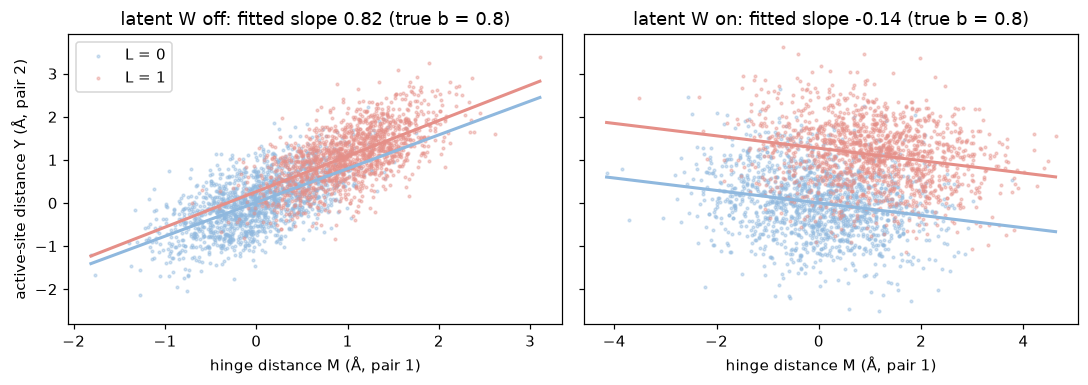

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for ax, (h, r) in zip(axs, res.items()):
    L, M, Y = r["data"]
    for lv, col in ((0, "#8fb8de"), (1, "#e58f88")):
        s = L == lv
        ax.scatter(M[s], Y[s], s=3, alpha=0.4, c=col, label=f"L = {lv}")
        slope, icpt = np.polyfit(M[s], Y[s], 1)
        mm = np.linspace(M.min(), M.max(), 10)
        ax.plot(mm, slope * mm + icpt, color=col, lw=2)
    ax.set_xlabel("hinge distance M (Å, pair 1)")
    ax.set_title(f"latent W {'on' if h else 'off'}: fitted slope {slope:.2f} (true b = {b_})")
axs[0].set_ylabel("active-site distance Y (Å, pair 2)"); axs[0].legend()
fig.tight_layout(); plt.show()

How wrong does the paired-pair estimate get as the hidden coupling grows? The
sweep below runs over the strength h of W → Y. The hinge-locking experiment is
immune to h, because do(M) removes W's path into M.

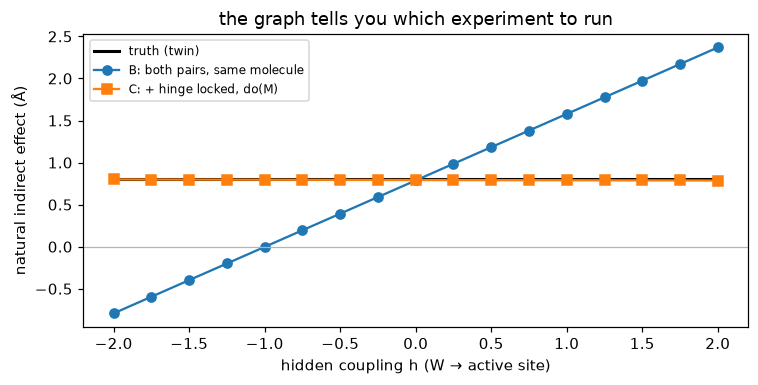

In [19]:
hs = np.linspace(-2, 2, 17)
sweep_h = [experiment(h if h != 0 else 1e-9, np.random.default_rng(10), n=40_000) for h in hs]
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(hs, [r["twin NIE"] for r in sweep_h], "k-", lw=2, label="truth (twin)")
ax.plot(hs, [r["B NIE"] for r in sweep_h], "o-", label="B: both pairs, same molecule")
ax.plot(hs, [r["C NIE"] for r in sweep_h], "s-", label="C: + hinge locked, do(M)")
ax.axhline(0, color="0.7", lw=0.8)
ax.set_xlabel("hidden coupling h (W → active site)"); ax.set_ylabel("natural indirect effect (Å)")
ax.set_title("the graph tells you which experiment to run"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

Three experimental designs, three answers:

| Design | Result |
|---|---|
| A: pairs measured on separate molecules | the total effect only; the pathway can't be split |
| B: both pairs on the same molecule (three-colour or paired traces) | right only without hidden coupling; with it the estimate can even change sign |
| C: an intervention on the mediator (a hinge lock) | right at every h |

## 4. Conformational selection or induced fit? (per binding event)

Surface-immobilised molecules are watched in frames of 0.2 ms. The binding event
is visible (a labelled ligand), and each frame reports open or closed. The
traces come from tttrlib's continuous-time Markov kinetics
(`sim_state_at_times`) on four states: open/closed × apo/bound.

| Mechanism | Binds from | Closed lifetime when bound | Opening when bound |
|---|---|---|---|
| Conformational selection (CS) | closed | longer | unchanged |
| Induced fit (IF) | open | — | the ligand drives closure |

The counterfactual for each event is the **probability of necessity**:
PN = P(open after Δ *had the ligand not bound* | bound, closed after Δ).

The conformation is modelled as a Gumbel-max SCM (Oberst & Sontag 2019).
- Each frame's transition is the argmax of log-probabilities plus Gumbel noise g_t.
- Abduction samples the g_t that reproduce the observed frames.
- The ligand-free twin reuses them with the apo transition matrix.

A chain sampled at frames *is* a discrete Markov chain, so the construction is
exact for these data. Abduction and replay run in C++,
`IMP.bff.CounterfactualMarkovChain`.

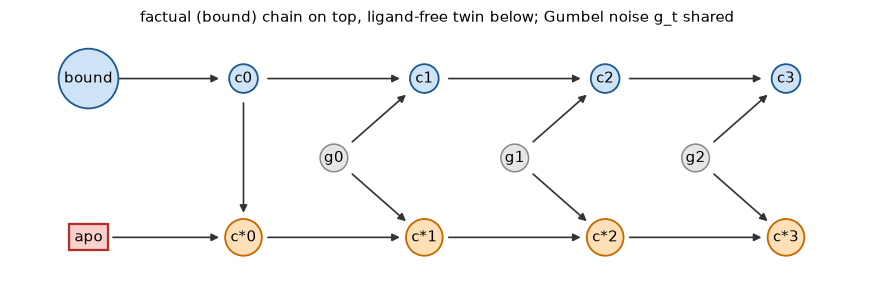

In [20]:
fig, ax = plt.subplots(figsize=(10, 3))
nodes = {}
edges = []
for t in range(4):
    nodes[f"c{t}"] = (1.4 * t, 1, "obs")
    nodes[f"c*{t}"] = (1.4 * t, -1, "cf")
    if t < 3:
        nodes[f"g{t}"] = (1.4 * t + 0.7, 0, "noise")
        edges += [(f"c{t}", f"c{t+1}"), (f"c*{t}", f"c*{t+1}"), (f"g{t}", f"c{t+1}"), (f"g{t}", f"c*{t+1}")]
nodes["bound"] = (-1.2, 1, "obs"); nodes["apo"] = (-1.2, -1, "do")
edges += [("bound", "c0"), ("apo", "c*0"), ("c0", "c*0")]
draw_graph(ax, nodes, edges, "factual (bound) chain on top, ligand-free twin below; Gumbel noise g_t shared")
plt.show()

In [21]:
FRAME, KON = 0.2, 0.05                            # ms, ms^-1
APO = dict(oc=0.1, co=0.1)                        # open->closed, closed->open (ms^-1)
MECH = {"CS": dict(bind_from=1, oc=0.1, co=0.02),
        "IF": dict(bind_from=0, oc=1.0, co=0.02)}

def propagator(oc, co, dt=FRAME):
    pi = np.array([co, oc]) / (oc + co)
    return pi[None, :] + (np.eye(2) - pi[None, :]) * np.exp(-(oc + co) * dt)

def rate_matrix(m):                               # states: 0 O-apo, 1 C-apo, 2 O-bound, 3 C-bound
    Q = np.zeros((4, 4))
    Q[0, 1], Q[1, 0] = APO["oc"], APO["co"]
    Q[2, 3], Q[3, 2] = m["oc"], m["co"]
    Q[m["bind_from"], m["bind_from"] + 2] = KON
    return Q

def binding_events(m, n, seed, frames_after=20):
    Q = tttrlib.VectorDouble(rate_matrix(m).ravel().tolist())
    frames = tttrlib.VectorDouble(np.arange(0, 400, FRAME).tolist())
    events = []
    while len(events) < n:
        s = np.asarray(tttrlib.sim_state_at_times(Q, 4, frames, tttrlib.VectorDouble([0.5, 0.5, 0, 0]), seed))
        seed += 1
        tb = int(np.argmax(s >= 2))               # first bound frame
        if s[tb] >= 2 and 0 < tb and tb + frames_after < len(s):
            events.append(s[tb - 1: tb + frames_after + 1] % 2)   # conformation from the last apo frame
    return events

def twin_trajectories(conf, P_bound, P_apo, rng, n_samples=300):
    # IMP.bff.CounterfactualMarkovChain: abduct the Gumbel noise of every observed step
    # under the bound-world matrix, replay it with the ligand-free one -- in C++
    chain = IMP.bff.CounterfactualMarkovChain(P_bound.ravel(), 2)
    paths = chain.get_counterfactual_trajectories([int(s) for s in conf], P_apo.ravel(), n_samples,
                                                  int(rng.integers(2 ** 31)))
    return np.reshape(paths, (n_samples, len(conf)))      # n_samples x frames

rng = np.random.default_rng(5)
P_apo = propagator(**APO)
P_bound = {name: propagator(m["oc"], m["co"]) for name, m in MECH.items()}
events = {name: binding_events(m, 200, seed=100) for name, m in MECH.items()}

def pn_at(name, delta):
    pns = [(twin_trajectories(c[:delta + 2], P_bound[name], P_apo, rng)[:, -1] == 0).mean()
           for c in events[name] if c[delta + 1] == 1]
    return np.array(pns)

DELTA = 10                                        # 2 ms after binding
pn = {name: pn_at(name, DELTA) for name in MECH}
for name in MECH:
    print(f"{name}: {len(pn[name])} events closed after {DELTA * FRAME:.0f} ms, mean PN = {pn[name].mean():.2f}")

CS: 188 events closed after 2 ms, mean PN = 0.14
IF: 176 events closed after 2 ms, mean PN = 0.80


One event of each kind. The black line is the factual trace. The shaded curve
is the fraction of abducted twins that are open in each frame: what *this*
molecule would have done without the ligand.

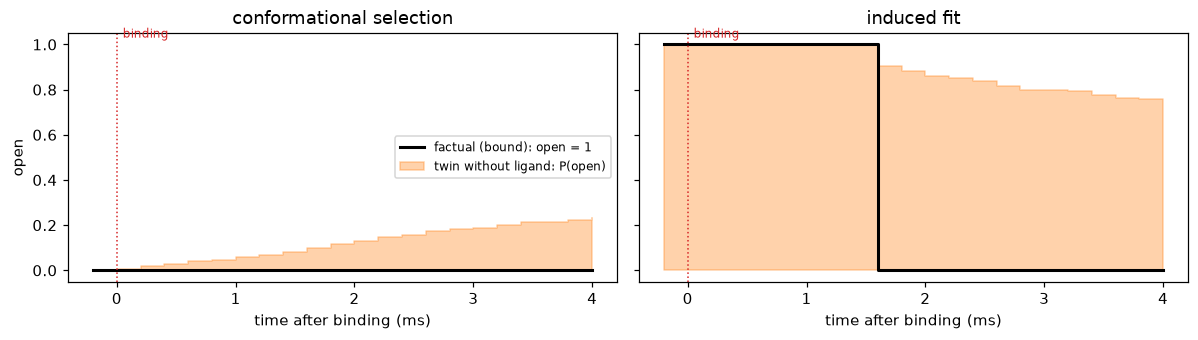

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
for ax, name in zip(axs, MECH):
    conf = next(c for c in events[name] if c[DELTA + 1] == 1)
    tw = twin_trajectories(conf, P_bound[name], P_apo, rng, n_samples=500)
    tt = (np.arange(len(conf)) - 1) * FRAME
    ax.step(tt, 1 - conf, where="post", color="k", lw=2, label="factual (bound): open = 1")
    ax.fill_between(tt, 0, (tw == 0).mean(0), step="post", alpha=0.35, color="C1",
                    label="twin without ligand: P(open)")
    ax.axvline(0, color="C3", ls=":", lw=1); ax.text(0.05, 1.03, "binding", color="C3", fontsize=8)
    ax.set_xlabel("time after binding (ms)"); ax.set_title({"CS": "conformational selection", "IF": "induced fit"}[name])
axs[0].set_ylabel("open"); axs[0].legend(fontsize=8, loc="center right")
fig.tight_layout(); plt.show()

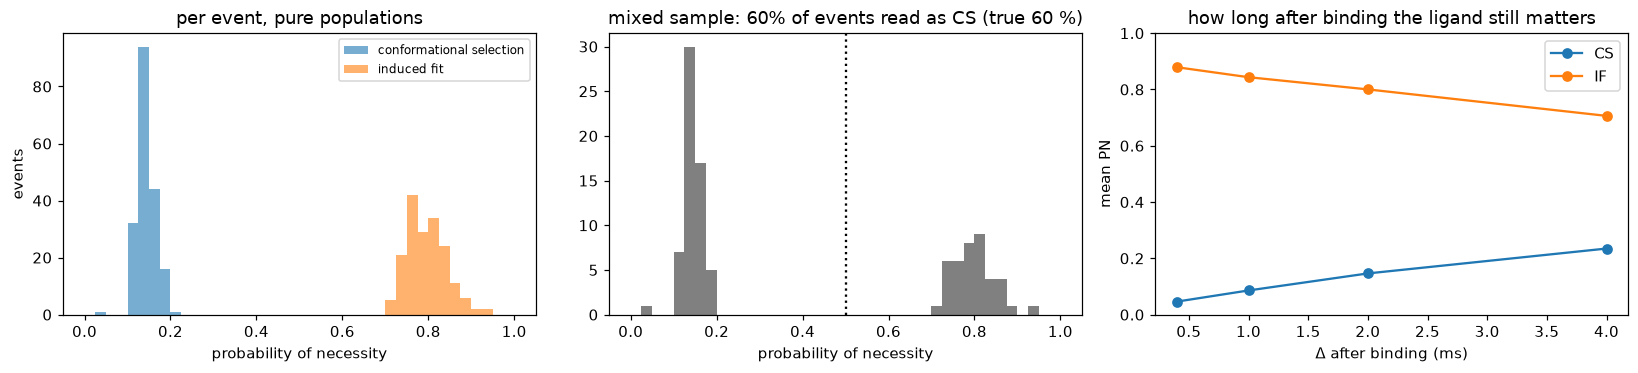

In [23]:
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(15, 3.5))
bins = np.linspace(0, 1, 41)
for name, label in (("CS", "conformational selection"), ("IF", "induced fit")):
    ax0.hist(pn[name], bins, alpha=0.6, label=label)
ax0.set_xlabel("probability of necessity"); ax0.set_ylabel("events"); ax0.legend(fontsize=8)
ax0.set_title("per event, pure populations")
mixed = np.r_[pn["CS"][:60], pn["IF"][:40]]       # 60 % CS, 40 % IF, labels hidden
ax1.hist(mixed, bins, color="0.5")
ax1.axvline(0.5, color="k", ls=":")
ax1.set_xlabel("probability of necessity"); ax1.set_title(
    f"mixed sample: {np.mean(mixed < 0.5):.0%} of events read as CS (true 60 %)")
deltas = [2, 5, 10, 20]
for name in MECH:
    ax2.plot([d * FRAME for d in deltas], [pn_at(name, d).mean() for d in deltas], "o-", label=name)
ax2.set_xlabel("Δ after binding (ms)"); ax2.set_ylabel("mean PN"); ax2.set_ylim(0, 1); ax2.legend()
ax2.set_title("how long after binding the ligand still matters")
fig.tight_layout(); plt.show()

In a mixed population the per-event PN is bimodal, and the fraction of events
following each mechanism is read off directly. An ensemble kinetic-model
comparison averages that mixture away. Under CS, PN is not zero: the ligand
does extend the closed lifetime, so it is partly necessary, and more so the
longer one waits.

## 5. Label perturbation as an inferred quantity (level 2)

Every FRET-restrained structure assumes that "dyes don't perturb the
structure", i.e. that the arrow label → conformation is absent. Instead, keep
the arrow and infer its strength.

The model, for each labelled pair i:
- a structural coordinate θ (say, domain opening in Å) moves its distance by
  a_i·θ;
- the dyes perturb it by β·s_i, where s_i is the pair's known susceptibility
  (for example, dyes near the moving interface);
- y_i = a_i·θ + β·s_i + ε.

With one pair, θ and β trade off along a ridge. Pairs with different ratios
s_i / a_i are different interventions, do(site), and they separate the two.

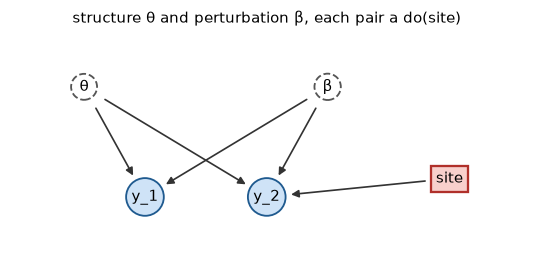

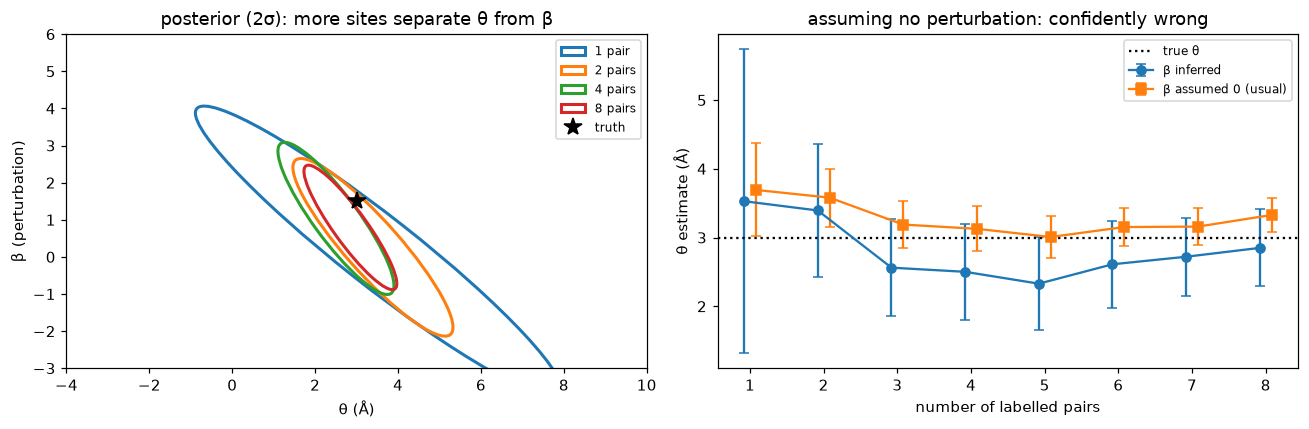

In [24]:
fig, ax = plt.subplots(figsize=(6, 2.6))
draw_graph(ax, {"θ": (0, 1, "latent"), "β": (2, 1, "latent"), "site": (3, 0, "do"),
                "y_1": (0.5, -0.2, "obs"), "y_2": (1.5, -0.2, "obs")},
           [("θ", "y_1"), ("θ", "y_2"), ("β", "y_1"), ("β", "y_2"), ("site", "y_2")],
           "structure θ and perturbation β, each pair a do(site)")
plt.show()

rng = np.random.default_rng(7)
theta_true, beta_true, sigma = 3.0, 1.5, 0.5
a_all = rng.uniform(0.3, 1.0, 8)                   # sensitivity of each pair to θ
s_all = rng.uniform(0.0, 1.0, 8)                   # perturbation susceptibility of each pair
y_all = a_all * theta_true + beta_true * s_all + rng.normal(0, sigma, 8)
prior_cov = np.diag([10.0 ** 2, 2.0 ** 2])         # θ, β

def posterior(n_pairs, with_beta=True):
    X = np.c_[a_all[:n_pairs], s_all[:n_pairs]]
    if not with_beta:
        X = X[:, :1]
    P0 = np.linalg.inv(prior_cov if with_beta else prior_cov[:1, :1])
    cov = np.linalg.inv(P0 + X.T @ X / sigma ** 2)
    return cov @ X.T @ y_all[:n_pairs] / sigma ** 2, cov

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4))
for n_pairs, col in zip((1, 2, 4, 8), ("C0", "C1", "C2", "C3")):
    mu, cov = posterior(n_pairs)
    vals, vecs = np.linalg.eigh(cov)
    ang = np.degrees(np.arctan2(vecs[1, 1], vecs[0, 1]))
    ax0.add_patch(Ellipse(mu, 4 * np.sqrt(vals[1]), 4 * np.sqrt(vals[0]), angle=ang,
                          fill=False, color=col, lw=2, label=f"{n_pairs} pair{'s' if n_pairs > 1 else ''}"))
ax0.plot(theta_true, beta_true, "k*", ms=12, label="truth")
ax0.set_xlim(-4, 10); ax0.set_ylim(-3, 6); ax0.set_xlabel("θ (Å)"); ax0.set_ylabel("β (perturbation)")
ax0.legend(fontsize=8); ax0.set_title("posterior (2σ): more sites separate θ from β")
ns = np.arange(1, 9)
th_with = [posterior(k)[0][0] for k in ns]; sd_with = [np.sqrt(posterior(k)[1][0, 0]) for k in ns]
th_wo = [posterior(k, False)[0][0] for k in ns]; sd_wo = [np.sqrt(posterior(k, False)[1][0, 0]) for k in ns]
ax1.errorbar(ns - 0.08, th_with, sd_with, fmt="o-", capsize=3, label="β inferred")
ax1.errorbar(ns + 0.08, th_wo, sd_wo, fmt="s-", capsize=3, label="β assumed 0 (usual)")
ax1.axhline(theta_true, color="k", ls=":", label="true θ")
ax1.set_xlabel("number of labelled pairs"); ax1.set_ylabel("θ estimate (Å)"); ax1.legend(fontsize=8)
ax1.set_title("assuming no perturbation: confidently wrong")
fig.tight_layout(); plt.show()

Ignoring the perturbation gives a θ that is precise and biased, and more data
make it *more* confidently wrong. Inferring β costs some precision and keeps
the truth inside the error bar. The structure reported is then the
counterfactual "unlabelled" one, with the perturbation's uncertainty carried
along.

## 6. Testing a FRET network: can a correct analysis give the wrong answer?

Yes, it can. Take a network of measured distances, fit the structural models,
and pick the best one. Every step can be done right, and the conclusion can
still be wrong when an assumption fails. A dye that sticks, an AV model that
misses a linker interaction, or a κ² far from 2/3 all show up as a **bias at
one labelling site**, carried into every pair that uses it. The fit then
absorbs that bias into the structure.

Counterfactuals don't detect a wrong model by magic: a bias that the network
can't distinguish from structure is not identifiable. What they add is
*explicit* questions about the conclusion, each one answerable:

1. **Abduction with the assumption made explicit.** Give every site a bias
   b_s, an exogenous variable with a prior. Network redundancy (each site in
   several pairs) makes b_s partly identifiable.
2. **do(b = 0).** What would the data have been with ideal dyes, keeping this
   experiment's noise? What structure does the standard analysis then pick?
3. **do(b_s = 0), one site at a time.** Which site does the conclusion
   *hinge* on? This is the probability-of-necessity idea from section 4,
   applied to an assumption.
4. **Counterfactual replay.** Had the structure been f′, with this very
   experiment's dye behaviour and noise, would the pipeline have found f′?
   The result is a calibration curve specific to *this* data set.

The structures are the 58 frames of the recorded hGBP1 transition (the
workshop's molecule). The distances are ⟨R_DA⟩_E computed with **IMP.bff**
accessible volumes (Alexa488 and Alexa647) at eight sites.

In [25]:
import itertools
import pathlib
import sys
here = pathlib.Path.cwd()
for candidate in (here, here / "doc" / "workshop", here.parent):
    if (candidate / "workshop.py").exists():
        sys.path.insert(0, str(candidate))
        break
import workshop as ws

frame0 = ws.hgbp1_state(0)
chain_range = {}
for line in open(frame0):
    if line.startswith("ATOM"):
        c, r = line[21], int(line[22:26])
        lo, hi = chain_range.get(c, (r, r)); chain_range[c] = (min(lo, r), max(hi, r))
chain_of = lambda r: next(c for c, (lo, hi) in chain_range.items() if lo <= r <= hi)

SITES = [18, 100, 177, 254, 344, 410, 481, 540]
N_FRAMES = ws.hgbp1_n_frames()
t0 = time.time()
R = np.zeros((N_FRAMES, len(SITES), len(SITES)))
for f in range(N_FRAMES):
    path = ws.hgbp1_state(f)
    donors = {s: ws.av(path, chain_of(s), s, "Alexa488") for s in SITES}
    acceptors = {s: ws.av(path, chain_of(s), s, "Alexa647") for s in SITES}
    for i, j in itertools.combinations(range(len(SITES)), 2):
        R[f, i, j] = ws.rda_e(donors[SITES[i]], acceptors[SITES[j]])
all_pairs = list(itertools.combinations(range(len(SITES)), 2))
Mfull = np.array([[R[f, i, j] for i, j in all_pairs] for f in range(N_FRAMES)])
readable = (Mfull.min(0) > 25) & (Mfull.max(0) < 95)          # E stays measurable along the path
MODEL = Mfull[:, readable]
PAIRS = [p for p, ok in zip(all_pairs, readable) if ok]
A_INC = np.zeros((len(PAIRS), len(SITES)))                    # which sites each pair uses
for k, (i, j) in enumerate(PAIRS):
    A_INC[k, i] = A_INC[k, j] = 1
print(f"{2 * len(SITES) * N_FRAMES} accessible volumes in {time.time() - t0:.1f} s; "
      f"{len(PAIRS)} readable pairs; pairs per site: {dict(zip(SITES, A_INC.sum(0).astype(int)))}")

928 accessible volumes in 8.2 s; 21 readable pairs; pairs per site: {18: np.int64(7), 100: np.int64(5), 177: np.int64(5), 254: np.int64(5), 344: np.int64(7), 410: np.int64(3), 481: np.int64(4), 540: np.int64(6)}


The causal graph of the network:
- The structure f sets every model distance.
- Each pair's measurement adds the biases of its two sites and noise.
- The standard analysis assumes b = 0, i.e. it deletes the bias nodes.

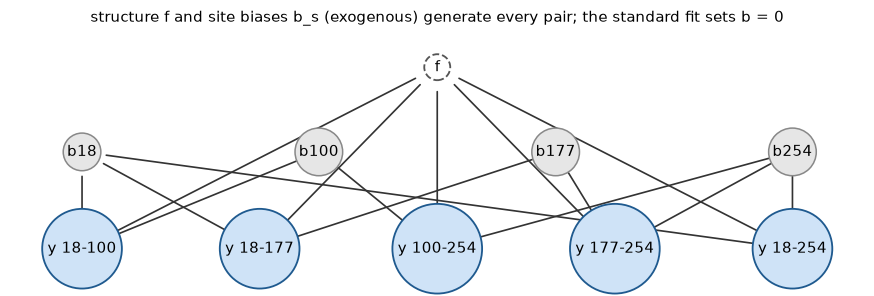

In [26]:
fig, ax = plt.subplots(figsize=(10, 3))
nodes = {"f": (3, 2, "latent")}
edges = []
for s in range(4):
    nodes[f"b{SITES[s]}"] = (2 * s, 0.6, "noise")
for k, (i, j) in enumerate([(0, 1), (0, 2), (1, 3), (2, 3), (0, 3)]):
    name = f"y {SITES[i]}-{SITES[j]}"
    nodes[name] = (1.5 * k, -1, "obs")
    edges += [("f", name), (f"b{SITES[i]}", name), (f"b{SITES[j]}", name)]
draw_graph(ax, nodes, edges, "structure f and site biases b_s (exogenous) generate every pair; the standard fit sets b = 0")
plt.show()

In [27]:
F_TRUE, BAD_SITE, BIAS, NOISE = 45, 0, 6.0, 1.0      # hidden from the analysis
SIGMA, TAU_B = 2.0, 3.0                               # reported error per pair; prior width of a site bias
rng = np.random.default_rng(1)
b_true = np.zeros(len(SITES)); b_true[BAD_SITE] = BIAS
y_obs = MODEL[F_TRUE] + A_INC @ b_true + rng.normal(0, NOISE, len(PAIRS))

# The analysis runs in C++: IMP.bff.CounterfactualDistanceNetwork
net = IMP.bff.CounterfactualDistanceNetwork(MODEL.ravel(), N_FRAMES, np.ravel(PAIRS).tolist(), len(SITES))
net.set_measurement(y_obs, [SIGMA] * len(PAIRS))
net.set_site_bias_prior([TAU_B] * len(SITES))
w_std = np.asarray(net.get_candidate_posterior(False))    # what is usually done: biases assumed zero
w_aware = np.asarray(net.get_candidate_posterior(True))   # site biases integrated out
b_f = np.reshape(net.get_site_biases_given_candidates(), (N_FRAMES, len(SITES)))   # E[b | y, f]
b_hat = np.asarray(net.get_abducted_site_biases())
chi2 = np.asarray(net.get_chi2())
print(f"truth: frame {F_TRUE}, +{BIAS:.0f} Å at site {SITES[BAD_SITE]}")
print(f"standard analysis : frame {w_std.argmax()}, P(true frame) = {w_std[F_TRUE]:.3f}, "
      f"reduced chi2 = {chi2.min() / (len(PAIRS) - 1):.2f}   <- looks acceptable")
print(f"bias-aware model  : frame {w_aware.argmax()}, P(true frame) = {w_aware[F_TRUE]:.2f}")
print("abducted site biases (Å):", {s: round(float(v), 1) for s, v in zip(SITES, b_hat)})

truth: frame 45, +6 Å at site 18
standard analysis : frame 57, P(true frame) = 0.000, reduced chi2 = 1.83   <- looks acceptable
bias-aware model  : frame 45, P(true frame) = 0.53
abducted site biases (Å): {18: 5.2, 100: 0.4, 177: 0.4, 254: 0.1, 344: -0.6, 410: 0.3, 481: 0.3, 540: -0.2}


The standard fit is confident and wrong, and its χ² gives no alarm. Now the
counterfactual questions:

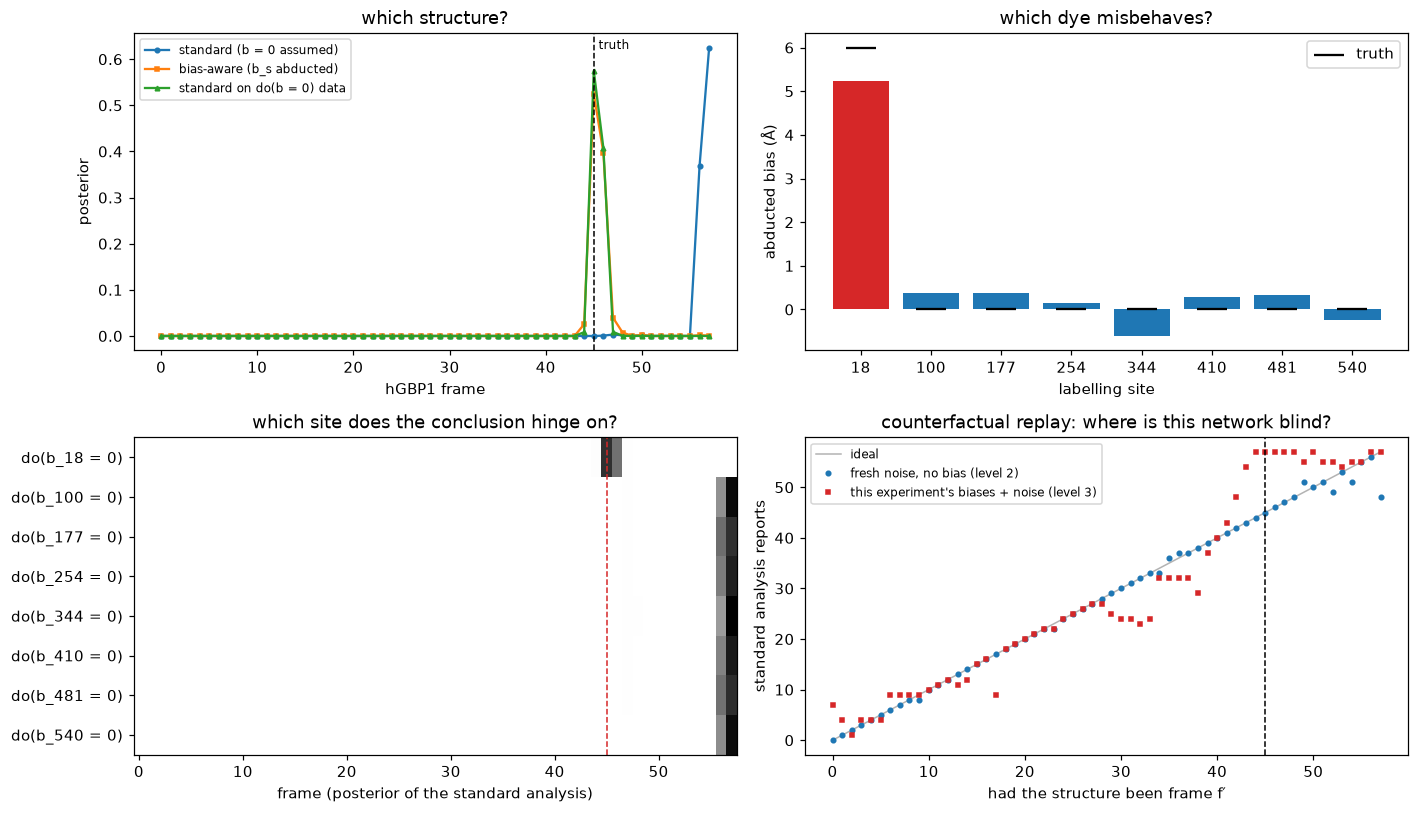

In [28]:
y_ideal = np.asarray(net.get_ideal_measurement())                        # 2. do(b = 0): ideal dyes, same noise
w_ideal = np.asarray(net.get_standard_posterior(y_ideal))
hinge = np.reshape(net.get_hinge_posteriors(), (len(SITES), N_FRAMES))   # 3. do(b_s = 0), one site at a time
replay = np.asarray(net.get_counterfactual_replay())                     # 4. this experiment's biases + noise
fresh = np.asarray(net.get_fresh_noise_replay(7))                        #    level 2: fresh noise, no bias

frames = np.arange(N_FRAMES)
fig, axs = plt.subplots(2, 2, figsize=(13, 7.5))
ax = axs[0, 0]
ax.plot(frames, w_std, "o-", ms=3, label="standard (b = 0 assumed)")
ax.plot(frames, w_aware, "s-", ms=3, label="bias-aware (b_s abducted)")
ax.plot(frames, w_ideal, "^-", ms=3, label="standard on do(b = 0) data")
ax.axvline(F_TRUE, color="k", ls="--", lw=1)
ax.text(F_TRUE + 0.5, 0.95, "truth", fontsize=8, transform=ax.get_xaxis_transform())
ax.set_xlabel("hGBP1 frame"); ax.set_ylabel("posterior"); ax.legend(fontsize=8); ax.set_title("which structure?")
ax = axs[0, 1]
ax.bar(range(len(SITES)), b_hat, color=["C3" if s == BAD_SITE else "C0" for s in range(len(SITES))])
ax.scatter(range(len(SITES)), b_true, marker="_", s=400, color="k", label="truth")
ax.set_xticks(range(len(SITES)), [str(s) for s in SITES]); ax.set_xlabel("labelling site")
ax.set_ylabel("abducted bias (Å)"); ax.legend(); ax.set_title("which dye misbehaves?")
ax = axs[1, 0]
im = ax.imshow(hinge, aspect="auto", cmap="Greys", extent=[-0.5, N_FRAMES - 0.5, len(SITES) - 0.5, -0.5])
ax.set_yticks(range(len(SITES)), [f"do(b_{s} = 0)" for s in SITES]); ax.axvline(F_TRUE, color="C3", ls="--", lw=1)
ax.set_xlabel("frame (posterior of the standard analysis)"); ax.set_title("which site does the conclusion hinge on?")
ax = axs[1, 1]
ax.plot(frames, frames, color="0.7", lw=1, label="ideal")
ax.plot(frames, fresh, "o", ms=3, color="C0", label="fresh noise, no bias (level 2)")
ax.plot(frames, replay, "s", ms=3, color="C3", label="this experiment's biases + noise (level 3)")
ax.axvline(F_TRUE, color="k", ls="--", lw=1)
ax.set_xlabel("had the structure been frame f′"); ax.set_ylabel("standard analysis reports")
ax.legend(fontsize=8); ax.set_title("counterfactual replay: where is this network blind?")
fig.tight_layout(); plt.show()

Reading the four panels:

| Panel | What it shows |
|---|---|
| Top left | The standard fit lands on the end of the transition. Abducting the site biases puts the posterior back on the truth, and so does the standard fit on the do(b = 0) data. |
| Top right | The bias is recovered at the right site, because site 18 sits in seven pairs that disagree with each other only through it. |
| Bottom left | Only do(b₁₈ = 0) moves the conclusion. The result *hinges* on one dye, and that is the dye to re-measure: label a different residue nearby, or swap donor and acceptor. Either is an intervention. |
| Bottom right | With fresh noise and no bias (level 2), the network recovers every frame. With *this experiment's* abducted biases, the whole last third of the transition collapses onto its end. |

That is the network test: not "is the fit good?" but "had the structure been
different, would this data set have shown it?".

Limits, as in section 5:
- A bias at a site that appears in only one or two pairs is not
  distinguishable from structure. The prior width τ_b then decides, and the
  counterfactual says so honestly: the posterior over frames stays broad.
- The structure space here is the 58 frames. A structure outside the library
  is a different, untested assumption.
- Site-level bias is one mechanism. κ², linker models or label perturbation
  (β, section 5) enter the graph the same way, as exogenous variables with
  priors.

### The network on the structure

The same result in 3D. Left is the truth (frame 45); right is what the standard
fit reports (frame 57). The clouds are the IMP.bff accessible volumes of the
donor dye at the eight sites, and the dye at residue 18, the one that
misbehaves, is drawn in red. The viewer loads Mol* from a CDN in the browser.

In [29]:
BAD_COLOUR, SITE_COLOUR = 0xC0392B, 0x3F6EA8

def network_view(frame, title):
    path = ws.hgbp1_state(frame)
    clouds = [{"pdb": ws.av_pdb(ws.av(path, chain_of(s), s, "Alexa488"), max_points=300),
               "colour": BAD_COLOUR if i == BAD_SITE else SITE_COLOUR, "label": str(s)}
              for i, s in enumerate(SITES)]
    return {"title": title, "structure": ws.protein_for_view(path), "clouds": clouds}

ws.show([network_view(F_TRUE, f"truth: frame {F_TRUE}"),
         network_view(int(w_std.argmax()), f"standard fit: frame {int(w_std.argmax())}")], height=460)

A static version, with the network drawn on the protein. Each edge joins the
mean dye positions of a pair and is coloured by its residual.

1. **Left:** the residuals of the standard fit against its answer, frame 57.
2. **Middle:** the residuals of the bias-aware fit against frame 45, after
   removing the abducted site biases (do(b = 0)).
3. **Right:** what each edge *would* have read had site 18's dye behaved,
   against what was measured: the counterfactual correction itself.

Frame 57 is superposed on frame 45 in the left panel, in grey.

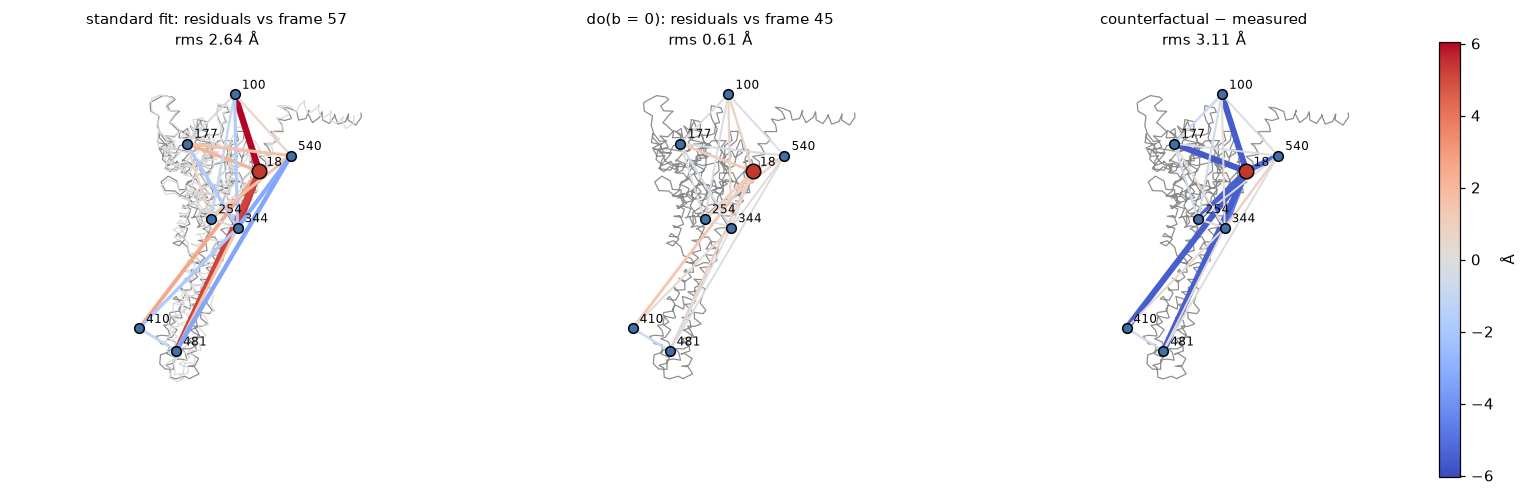

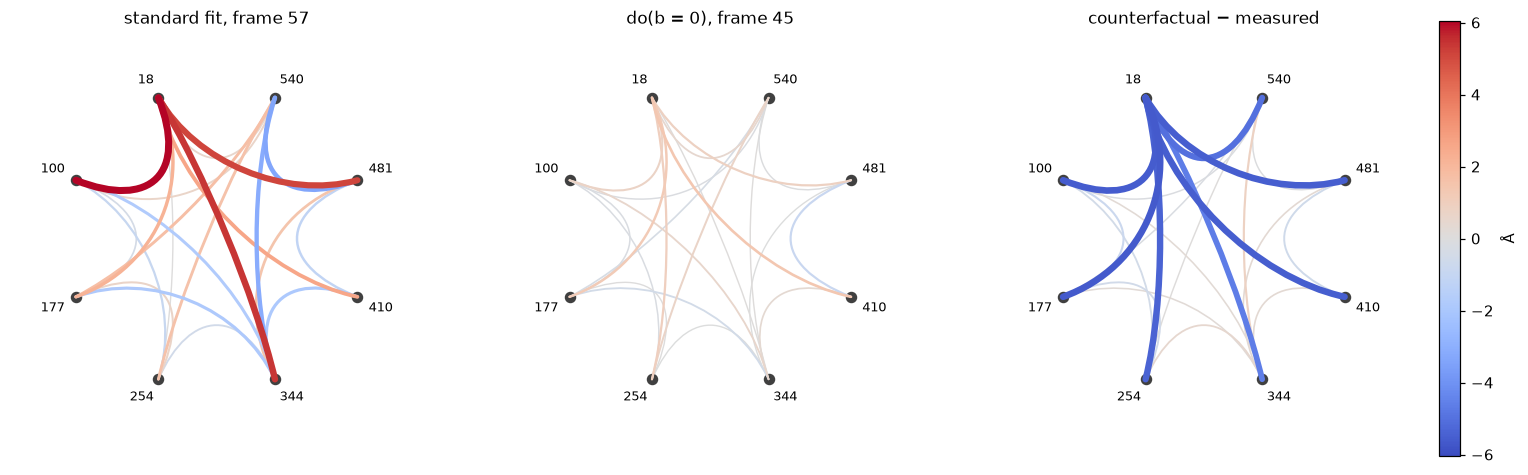

In [30]:
def ca_and_dyes(frame):
    path = ws.hgbp1_state(frame)
    ca = np.array([[float(l[30:38]), float(l[38:46]), float(l[46:54])]
                   for l in open(path) if l.startswith("ATOM") and l[12:16].strip() == "CA"])
    dyes = np.array([np.asarray(ws.av_points(ws.av(path, chain_of(s), s, "Alexa488")))[:, :3].mean(0) for s in SITES])
    return ca, dyes

def kabsch(mobile, target):
    mc, tc = mobile.mean(0), target.mean(0)
    u, _, vt = np.linalg.svd((mobile - mc).T @ (target - tc))
    d = np.sign(np.linalg.det(u @ vt))
    rot = u @ np.diag([1, 1, d]) @ vt
    return lambda x: (x - mc) @ rot + tc

ca_true, dye_true = ca_and_dyes(F_TRUE)
f_std = int(w_std.argmax())
ca_std, dye_std = ca_and_dyes(f_std)
fit = kabsch(ca_std, ca_true)
ca_std, dye_std = fit(ca_std), fit(dye_std)

res_std = y_obs - MODEL[f_std]                        # standard fit, its own answer
res_aware = (y_obs - A_INC @ b_hat) - MODEL[F_TRUE]   # do(b = 0) data against the bias-aware answer
shift_cf = -A_INC @ b_hat                             # counterfactual minus measured
VMAX3 = float(np.max(np.abs(np.r_[res_std, res_aware, shift_cf])))
norm, cmap = ws.deviation_scale(VMAX3)

fig = plt.figure(figsize=(17, 6.5))
panels = [(ca_true, dye_true, res_std, f"standard fit: residuals vs frame {f_std}", ca_std),
          (ca_true, dye_true, res_aware, f"do(b = 0): residuals vs frame {F_TRUE}", None),
          (ca_true, dye_true, shift_cf, "counterfactual − measured", None)]
for k, (ca, dyes, vals, title, ghost) in enumerate(panels):
    ax = fig.add_subplot(1, 3, k + 1, projection="3d")
    ax.plot(*ca.T, color="0.55", lw=0.8)
    if ghost is not None:
        ax.plot(*ghost.T, color="0.85", lw=0.8)
    for (i, j), v in zip(PAIRS, vals):
        ax.plot(*np.c_[dyes[i], dyes[j]], color=cmap(norm(v)), lw=1.2 + 3 * abs(v) / VMAX3)
    for i, s in enumerate(SITES):
        ax.scatter(*dyes[i], s=90 if i == BAD_SITE else 40, color="#c0392b" if i == BAD_SITE else "#3f6ea8",
                   edgecolor="k", depthshade=False)
        ax.text(*(dyes[i] + 2), str(s), fontsize=8)
    ax.set_title(f"{title}\nrms {np.sqrt(np.mean(vals ** 2)):.2f} Å", fontsize=10)
    pts = np.r_[ca, dyes]
    lo, hi = pts.min(0) - 6, pts.max(0) + 6
    ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[1], hi[1]); ax.set_zlim(lo[2], hi[2])
    ax.set_box_aspect(hi - lo, zoom=1.15)
    ax.set_axis_off(); ax.view_init(elev=20, azim=-60)
fig.colorbar(ws.deviation_mappable(VMAX3), ax=fig.axes, fraction=0.015, pad=0.02, label="Å")
plt.show()

site_name = {i: str(s) for i, s in enumerate(SITES)}
named = [(site_name[i], site_name[j]) for i, j in PAIRS]
fig, axes = plt.subplots(1, 3, figsize=(17, 5.8))
for ax, vals, title in zip(axes, (res_std, res_aware, shift_cf),
                           (f"standard fit, frame {f_std}", f"do(b = 0), frame {F_TRUE}", "counterfactual − measured")):
    ws.circle_plot(named, dict(zip(named, vals)), ax=ax, vmax=VMAX3, colorbar=False, title=title)
fig.colorbar(ws.deviation_mappable(VMAX3), ax=axes, fraction=0.015, pad=0.02, label="Å")
plt.show()

The standard fit's largest residuals do sit on edges of residue 18. But the
fit has already moved the structure to frame 57 to absorb part of the bias,
pushing the error onto other pairs (the blue edges far from 18). The reduced
χ² of 1.8 doesn't say which site, or that the structure is wrong. After
do(b = 0), the residuals are noise. The correction itself, on the right, sits
on exactly the seven edges that touch residue 18. A per-site bias has this
signature, and the network's
redundancy is what makes it visible.

## 7. Direction on the factor graph

The mediation model of section 3 can be built in `IMP.bff.InferenceFactorGraph`:
the mechanisms are factors and the two FRET pairs are likelihoods.

In [31]:
def mediation_graph(reverse=False):
    G = IMP.bff.InferenceFactorGraph()
    for i, (key, role) in enumerate([("L", "intervention"), ("W", "exogenous"),
                                      ("M", "hinge"), ("Y", "active_site")]):
        G.add_variable(key, key, i, -1, 1, role)
    child, other = ("M", "Y") if not reverse else ("Y", "M")
    G.add_factor(f"f_{child}", IMP.bff.INFERENCE_FACTOR_PRIOR, ["L", "W", child])
    G.add_factor(f"f_{other}", IMP.bff.INFERENCE_FACTOR_PRIOR, ["L", "W", "M", "Y"])
    G.add_factor("pair1", IMP.bff.INFERENCE_FACTOR_LIKELIHOOD, ["M"], 0, 100)
    G.add_factor("pair2", IMP.bff.INFERENCE_FACTOR_LIKELIHOOD, ["Y"], 1, 100)
    return G

forward, backward = mediation_graph(), mediation_graph(reverse=True)
print(forward.describe())
print("cliques, hinge drives active site :", forward.get_cliques())
print("cliques, active site drives hinge :", backward.get_cliques())

variables      : 4 (4 free numbers)
likelihoods    : 2
priors         : 2
treewidth      : 3
components     : 1
separators     : (none - no shared parameters)

cliques, hinge drives active site : (('L', 'W', 'M', 'Y'),)
cliques, active site drives hinge : (('L', 'W', 'M', 'Y'),)


Both models give the same single clique, so the graph can't tell which way the
signal travels. Declaring each mechanism's child gives the graph its arrows,
and with them the operations a counterfactual needs:

1. **The moral graph** is what the factor graph keeps today: one undirected
   clique.
2. **The directed graph** is what a factor that carries its arrow keeps.
3. **intervene("M")** deletes the arrows into M.
4. **twin(["L"])** adds counterfactual copies that share the exogenous W.

In [32]:
forward.set_factor_children("f_M", ["M"])        # p(M | L, W): a mechanism
forward.set_factor_children("f_Y", ["Y"])        # p(Y | L, W, M)
print("parents of Y        :", list(forward.get_parents("Y")))
print("cliques, unchanged  :", forward.get_cliques() == backward.get_cliques())
print("\n== do(M): the hinge lock of experiment C ==")
print(forward.get_intervened(["M"]).describe())
twin = forward.get_twin(["L"])                   # factual + counterfactual world, W shared
print("== twin network for do(L) ==")
print(twin.describe())
print("parents of Y@cf     :", list(twin.get_parents("Y@cf")))

parents of Y        : ['L', 'W', 'M']
cliques, unchanged  : True

== do(M): the hinge lock of experiment C ==
variables      : 4 (4 free numbers)
likelihoods    : 2
priors         : 1
mechanisms     : 1 (acyclic)
intervened     : M
treewidth      : 3
components     : 1
separators     : (none - no shared parameters)

== twin network for do(L) ==
variables      : 7 (7 free numbers)
likelihoods    : 2
priors         : 4
mechanisms     : 4 (acyclic)
intervened     : L@cf
treewidth      : 3
components     : 1
separators     : {W}

parents of Y@cf     : ['W', 'L@cf', 'M@cf']


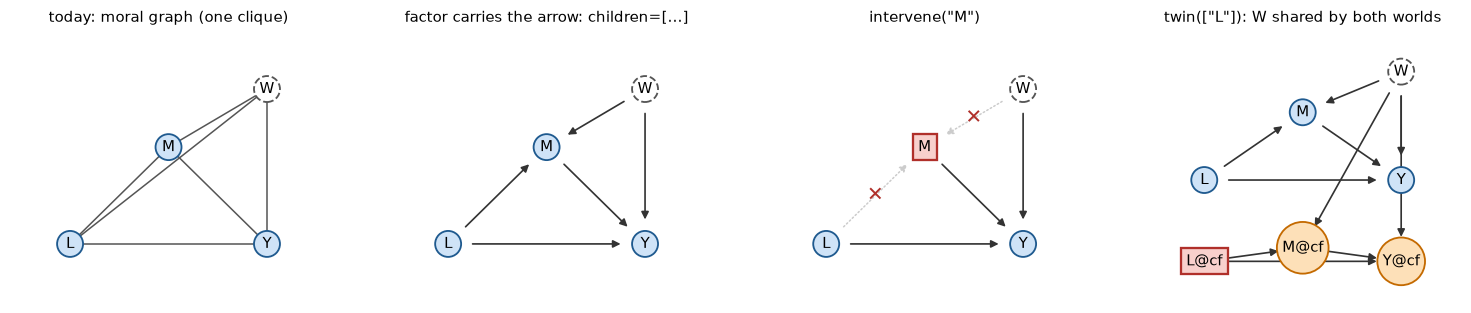

In [33]:
fig, axs = plt.subplots(1, 4, figsize=(17, 3.2))
pos = {"L": (0, 0), "M": (1, 1), "Y": (2, 0), "W": (2, 1.6)}
nodes = {k: (*p, "latent" if k == "W" else "obs") for k, p in pos.items()}
# 1: moral graph = undirected clique, drawn with plain lines
for (u, v) in [("L", "M"), ("L", "Y"), ("L", "W"), ("M", "Y"), ("M", "W"), ("Y", "W")]:
    axs[0].plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color="#555", lw=1, zorder=1)
draw_graph(axs[0], nodes, [], "today: moral graph (one clique)")
draw_graph(axs[1], nodes, [("L", "M"), ("M", "Y"), ("L", "Y"), ("W", "M"), ("W", "Y")],
           "factor carries the arrow: children=[...]")
draw_graph(axs[2], {**nodes, "M": (1, 1, "do")}, [("L", "M", "cut"), ("W", "M", "cut"), ("M", "Y"), ("L", "Y"), ("W", "Y")],
           'intervene("M")')
draw_graph(axs[3], {**nodes, "M@cf": (1, -1, "cf"), "Y@cf": (2, -1.2, "cf"), "L@cf": (0, -1.2, "do")},
           [("L", "M"), ("M", "Y"), ("L", "Y"), ("W", "M"), ("W", "Y"),
            ("L@cf", "M@cf"), ("M@cf", "Y@cf"), ("L@cf", "Y@cf"), ("W", "M@cf"), ("W", "Y@cf")],
           'twin(["L"]): W shared by both worlds')
plt.show()

The same calls exist in C++ (`examples/counterfactual/twin_factor_graph.cpp`):
- `set_factor_children(factor, children)` makes a factor a mechanism, p(children | rest of its scope);
- `get_parents`, `get_children`, `get_descendants`, `get_is_acyclic`;
- `get_intervened(keys)` gives the mutilated graph of do(keys);
- `get_twin(keys, suffix="@cf")` gives the twin network.

Points to keep in mind:
- **Without children,** a factor stays an undirected potential. The moral graph,
  cliques, treewidth and sampling blocks are the same with or without
  direction, as the check above shows.
- **Bidirected edges** (the latent W) are an `exogenous` variable that is a
  parent of both sides.
- **The data stay in the factual world:** data likelihoods are not copied into
  the twin.
- **A restraint on the counterfactual world** is a prior with role
  `assumption`. It is never a likelihood.

## 8. Go further

Each of these changes one assumption above; try them to see what breaks.

- **Section 2:**
  - Add crosstalk or γ ≠ 1 to the simulation, but not to the model. Which
    posterior absorbs the error, and how do the per-burst calls change?
  - Fix the exchange rates at a wrong value (narrow priors) and redo the
    abduction: the counterfactual depends on the mechanism, as section 1
    warned.
- **Section 3:** make the hinge lock imperfect: M = m_set + 0.3·W. Experiment C
  then inherits part of the bias.
- **Section 4:** give IF a non-zero closed→open rate when bound, or let
  ligand unbind (`k_off`). How does PN change with Δ?
- **Section 6:**
  - Move the bias to site 410 (three pairs) and watch the abducted bias
    become uncertain.
  - Add a redundant pair, or drop site 18, and redo the replay: which network
    has no blind spot?
- **Section 5:** make every pair equally susceptible (`s_all = 0.5`). θ and β
  are then confounded no matter how many pairs are measured; the site choice
  is the intervention that identifies β.

Further reading:
- J. Pearl, *Causality* (2009), ch. 7, on counterfactuals and twin networks.
- M. Oberst & D. Sontag, ICML 2019, on Gumbel-max structural causal models.
- V. Veitch et al., NeurIPS 2021, on counterfactual invariance
  ([arXiv:2106.00545](https://arxiv.org/abs/2106.00545)).
- D. Ibeling & T. Icard, AAAI 2020, on reasoning across the causal hierarchy.